In [25]:
import sdv
import sdmetrics
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import random
import itertools
import time
import math

from sdv.evaluation import single_table
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier

# Goal
We want to code our synthetic data generation experiments as simulations, i.e., rather than generating data sets once per method, we want to generate data sets *n* times per method, and then aggregrate data quality metrics. To do so, we will save (and export) tables of *metrics* rather than the synthetic data tables themselves.

### 1. Load Data
We want to generate synthetic data using the AIDS data set that was also used in the paper by Guillaudeaux et al. (2023): https://github.com/octopize/avatar-paper/blob/main/datasets/AIDS/aids_original_data.csv

In [42]:
from sdv.datasets.local import load_csvs

# assume that the current directory (./) contains the dataset
datasets = load_csvs("./")

data_all = datasets['aids_data']

/home/nikipetrakos/SyntheticData/Environments/SyntheticDataVaultTest/lib/python3.9/site-packages/sdv/datasets/local.py:34: UserWarning: Ignoring incompatible files ['aids_synthesizer_cd420_execmod.pkl', 'my_metadata.png', 'CTGAN_PythonCode_ToShare.ipynb', 'get-pip.py', 'aids_synthesizer_cd496_execmod.pkl', 'aids_baseline_metadata.json', 'aids_metadata_preprocessed.json', 'aids_cd496_execmod_metadata.json', 'aids_synthesizer_baseline.pkl', 'aids_synthesizer_outcome_execmod.pkl', 'aids_baseline_metadata_preprocessed.json', 'aids_synthesizer_all_preprocessed.pkl', 'CTGANwithAIDSdata.ipynb', 'my_synthesizer.pkl', 'SDVDemos.ipynb', 'SyntheticDataSimulation.ipynb', 'aids_metadata_continuouskarnofsky.json', 'aids_metadata.json', 'aids_cd420_execmod_metadata.json', 'aids_outcome_execmod_metadata.json', 'aids_synthesizer_all.pkl', 'aids_synthesizer_baseline_preprocessed.pkl'] in folder './'.
  warnings.warn(


### 2. Prepare data and metadata
Create all necessary data sets and metadata files for simulations.

#### 2.1 Simultaneous

##### 2.1.1 Data

In [43]:
# Remove columns that we will not use
# zprior, str2, cd80, cd820, r, treat, offtrt, days
data_all = data_all.drop(['zprior', 'str2', 'cd80', 'cd820', 'r', 'treat', 'offtrt', 'days'], axis=1)
data_all.head()

,pidnum,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,preanti,race,gender,strat,symptom,cd40,cd420,cd496,cens,arms
0,10056,48,89.8128,0,0,0,100,0,0,0,0,0,1,0,422,477,660.0,0,2
1,10059,61,49.4424,0,0,0,90,0,1,895,0,0,3,0,162,218,NaN,1,3
2,10089,45,88.4520,0,1,1,90,0,1,707,0,1,3,0,326,274,122.0,0,3
3,10093,47,85.2768,0,1,0,100,0,1,1399,0,1,3,0,287,394,NaN,0,3
4,10124,43,66.6792,0,1,0,100,0,1,1352,0,1,3,0,504,353,660.0,0,0


##### 2.1.2 Metadata

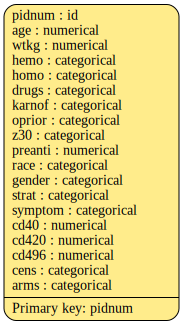

In [44]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()

metadata.detect_from_dataframe(data_all)

metadata.visualize(
    show_table_details='full',
    output_filepath='my_metadata.png'
)

In [45]:
metadata.validate()
metadata.validate_data(data = data_all)

In [ ]:
# Save as json file
metadata.save_to_json(filepath='aids_metadata.json') 

#### 2.2 Sequential

##### 2.2.1 Data

In [49]:
# Select the baseline variables columns, including the ID variable
data_baseline = data_all[['pidnum', 'age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 
                            'strat', 'symptom', 'cd40']]
data_baseline

,pidnum,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,preanti,race,gender,strat,symptom,cd40
0,10056,48,89.8128,0,0,0,100,0,0,0,0,0,1,0,422
1,10059,61,49.4424,0,0,0,90,0,1,895,0,0,3,0,162
2,10089,45,88.4520,0,1,1,90,0,1,707,0,1,3,0,326
3,10093,47,85.2768,0,1,0,100,0,1,1399,0,1,3,0,287
4,10124,43,66.6792,0,1,0,100,0,1,1352,0,1,3,0,504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2134,990021,21,53.2980,1,0,0,100,0,1,842,0,1,3,0,152
2135,990026,17,102.9672,1,0,0,100,0,1,417,1,1,3,0,373
2136,990030,53,69.8544,1,1,0,90,0,1,753,1,1,3,0,419
2137,990071,14,60.0000,1,0,0,100,0,0,0,0,1,1,0,166


In [31]:
# For CTGAN Sequential 1 (pre-process data)

# Apply log transform to cd40

data_all_preprocessed = data_all.copy()

# cd40 has instances have values = 0, which we cannot take the log of - set these to a small number (e.g., 0.5)
# handle these cases
data_all_preprocessed['cd40_log'] = np.where(data_all_preprocessed['cd40'] > 0, np.log(data_all_preprocessed['cd40']), 
                                             np.where(data_all_preprocessed['cd40'] == 0, 0.5, np.nan))

data_all_preprocessed['cd420_log'] = np.log(data_all_preprocessed['cd420'])

# cd496 has instances have values = 0, which we cannot take the log of - set these to a small number (e.g., 0.5)
# handle these cases
data_all_preprocessed['cd496_log'] = np.where(data_all_preprocessed['cd496'] > 0, np.log(data_all_preprocessed['cd496']), 
                                              np.where(data_all_preprocessed['cd496'] == 0, 0.5, np.nan))

# Remove original cd40, cd420, and cd496 columns
data_all_preprocessed = data_all_preprocessed.drop(['cd40', 'cd420', 'cd496'], axis=1)

data_all_preprocessed.head()

/home/nikipetrakos/SyntheticData/Environments/SyntheticDataVaultTest/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nikipetrakos/SyntheticData/Environments/SyntheticDataVaultTest/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,pidnum,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,preanti,race,gender,strat,symptom,cens,arms,cd40_log,cd420_log,cd496_log
0,10056,48,89.8128,0,0,0,100,0,0,0,0,0,1,0,0,2,6.045005,6.167516,6.492240
1,10059,61,49.4424,0,0,0,90,0,1,895,0,0,3,0,1,3,5.087596,5.384495,NaN
2,10089,45,88.4520,0,1,1,90,0,1,707,0,1,3,0,0,3,5.786897,5.613128,4.804021
3,10093,47,85.2768,0,1,0,100,0,1,1399,0,1,3,0,0,3,5.659482,5.976351,NaN
4,10124,43,66.6792,0,1,0,100,0,1,1352,0,1,3,0,0,0,6.222576,5.866468,6.492240


In [50]:
cd4wk20_data_learn = data_all[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                'symptom', 'cd40', 'arms', 'cd420']]

cd4wk96_data_learn = data_all[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                'symptom', 'cd40', 'arms', 'cd420', 'cd496']]

outcome_data_learn = data_all[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                'symptom', 'cd40', 'arms', 'cd420', 'cd496', 'cens']]


# For CTGAN Sequential 1 (pre-processed data), run the following instead:

# cd4wk20_data_learn = data_all_preprocessed[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
#                                             'symptom', 'cd40_log', 'arms', 'cd420_log']]

# cd4wk96_data_learn = data_all_preprocessed[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
#                                               'symptom', 'cd40_log', 'arms', 'cd420_log', 'cd496_log']]

# outcome_data_learn = data_all_preprocessed[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
#                                               'symptom', 'cd40_log', 'arms', 'cd420_log', 'cd496_log', 'cens']]

##### 2.2.2 Metadata

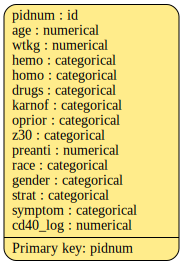

In [34]:
# For CTGAN Sequential 1 (pre-processed data)

from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()

metadata.detect_from_dataframe(data_baseline_preprocessed)

metadata.visualize(
    show_table_details='full',
    output_filepath='my_metadata.png'
)

In [35]:
metadata.validate()
metadata.validate_data(data = data_baseline_preprocessed)

In [ ]:
# Save as json file
metadata.save_to_json(filepath='aids_baseline_metadata_preprocessed.json')

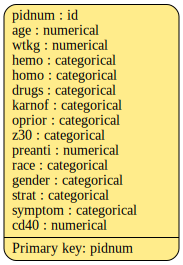

In [52]:
# For CTGAN Sequential 2-5 (NO pre-processed data)
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()

metadata.detect_from_dataframe(data_baseline)

metadata.visualize(
    show_table_details='full',
    output_filepath='my_metadata.png'
)

In [53]:
metadata.validate()
metadata.validate_data(data = data_baseline)

In [ ]:
# Save as json file
metadata.save_to_json(filepath='aids_baseline_metadata.json')

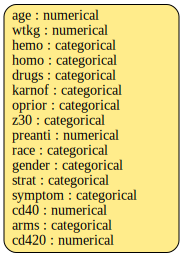

In [67]:
# Additional metadata for CTGAN Sequential 5 (CTGAN execution models)

from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()

metadata.detect_from_dataframe(cd4wk20_data_learn)

metadata.visualize(
    show_table_details='full',
    output_filepath='my_metadata.png'
)

In [68]:
metadata.validate()
metadata.validate_data(data = cd4wk20_data_learn)

In [ ]:
# Save as json file
metadata.save_to_json(filepath='aids_cd420_execmod_metadata.json')

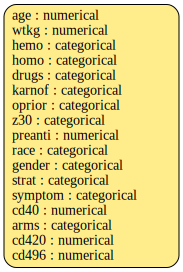

In [69]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()

metadata.detect_from_dataframe(cd4wk96_data_learn)

metadata.visualize(
    show_table_details='full',
    output_filepath='my_metadata.png'
)

In [70]:
metadata.validate()
metadata.validate_data(data = cd4wk96_data_learn)

In [ ]:
# Save as json file
metadata.save_to_json(filepath='aids_cd496_execmod_metadata.json')

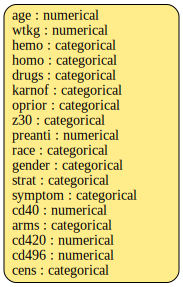

In [71]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()

metadata.detect_from_dataframe(outcome_data_learn)

metadata.visualize(
    show_table_details='full',
    output_filepath='my_metadata.png'
)

In [72]:
metadata.validate()
metadata.validate_data(data = outcome_data_learn)

In [ ]:
# Save as json file
metadata.save_to_json(filepath='aids_outcome_execmod_metadata.json')

### 3. Simulations

#### 3.1 CTGAN Simultaneous

In [46]:
# Load these functions first

# This function generates a data set using CTGAN and all data simultaneously (all at once). 
def ctgan_simultaneous(real_data, metadata, n_obs):
    """
    This function takes as input a real data set, its metadata, and the number of observations (rows) to generate,
    and outputs a synthetically-generated data set using the CTGAN Simultaneous data generation method.
    """

    # Train the synthesizer on all of the data
    synthesizer = sdv.single_table.CTGANSynthesizer(metadata)
    synthesizer.fit(real_data)

    # Generate data using the trained synthesizer
    synthetic_data = synthesizer.sample(num_rows = n_obs)

    # Specify the new column order
    col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", "race", "gender", "strat", "symptom",
                 "cd40", "arms", "cd420", "cd496", "cens"]
    
    # Reorder the DataFrame columns
    synthetic_data = synthetic_data[col_order]

    return synthetic_data


# Function to calculate Correlation Similarity USING SPEARMAN CORRELATION for all column pairs
def calculate_spearman_correlation_similarity(real_data, synthetic_data):
    column_pairs = list(itertools.combinations(real_data.columns, 2))
    results = []

    for col1, col2 in column_pairs:
        value = sdmetrics.column_pairs.CorrelationSimilarity.compute(real_data = real_data[[col1, col2]],
                                              synthetic_data = synthetic_data[[col1, col2]],
                                              coefficient = 'Spearman')
        results.append({
            'Column 1': (col1),
            'Column 2': (col2),
            'Metric': 'CorrelationSimilarity',
            'Score': value
        })

    return pd.DataFrame(results)


In [47]:
# This function generates n data sets using the CTGAN Simultaneous method and computes all metrics 
def ctgansimult_sim_eval(n, n_obs, real_data, metadata, col_order, col_cont, col_disc, random_seed):
    """
    This function takes as input:
    n: the number of data sets to generate (i.e., number of replications)
    n_obs: number of observations to generate per data set
    real_data: a real data set
    metadata: the metadata for the given real data set
    col_order: the order of columns in the real and synthetic data sets
    col_cont: the continuous columns in the real and synthetic data sets
    col_disc: the discrete columns in the real and synthetic data sets
    random_seed: an integer for the random seed

    This function outputs:
    a list containing the following dataframes containing metrics: univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn
    """

    # Initialize objects to store all metrics

    # Univariate continous
    univar_cont = pd.DataFrame(np.nan, index = range(n), columns = col_cont)

    # Univariate discrete
    univar_disc = pd.DataFrame(np.nan, index = range(n), columns = col_disc)

    # Bivariate
    bivar = pd.DataFrame(columns = ['Column 1', 'Column 2', 'Metric', 'Score'])

    # ML efficacy
    MLeff_xgb = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])
    MLeff_knn = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])

    # Trial inference
    infer = pd.DataFrame(columns = ['OR', 'Lower CI', 'Upper CI'])

    for i in range(0, n):

        # Generate data set
        data_synth = ctgan_simultaneous(real_data = real_data, metadata = metadata, n_obs = n_obs)

        # Compute univariate metrics for current data set
        quality_report = single_table.evaluate_quality(
            real_data = real_data,
            synthetic_data = data_synth,
            metadata = metadata,
            verbose = False  # don't print results
        )
        
        metrics_univar = quality_report.get_details(property_name = 'Column Shapes')

        # Save continuous univariate metrics
        metrics_univar_cont = metrics_univar[metrics_univar['Metric'] == 'KSComplement'].T
        univar_cont.iloc[i] = metrics_univar_cont.iloc[2]

        # Save discrete univariate metrics
        metrics_univar_disc = metrics_univar[metrics_univar['Metric'] == 'TVComplement'].T
        univar_disc.iloc[i] = metrics_univar_disc.iloc[2]

        # Compute bivariate metrics for current data set     
        metrics_bivar_pearson = quality_report.get_details(property_name = 'Column Pair Trends').iloc[:, :4]

        # Calculate Spearman Correlation Similarity for all pairs
        spearman_correlation_similarities = calculate_spearman_correlation_similarity(real_data[col_cont], data_synth[col_cont])

        # Use merge to remove Pearson correlation similarity scores and keep Spearman correlation similarity scores
        # Left merge
        merged_scores = metrics_bivar_pearson.merge(spearman_correlation_similarities, on = ['Column 1', 'Column 2', 'Metric'], how = 'left')
        
        # Create new Score column that keeps original contingency similarity score values 
        # but replaces Pearson with Spearman correlation similarity scores
        merged_scores['Score'] = np.where(merged_scores['Score_y'].notna(), merged_scores['Score_y'], merged_scores['Score_x'])
        
        # Remove old score columns
        bivar_scores_spear_contin = merged_scores[['Column 1', 'Column 2', 'Metric', 'Score']]

        # Save bivariate metrics
        bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)

        # Compute ML efficacy metrics - XGBoost

        # Split the real data into train and test
        # First, make sure columns are in the correct order
        data_real = real_data[col_order]
        
        X_real = data_real.drop(columns = ['pidnum', 'cens'])  # Features
        y_real = data_real['cens']                             # Outcome
        
        X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size = 0.3, 
                                                                                random_state = random_seed + i)
        
        # Split the synthetic data into train and test (though, note that we will only use the training set)
        data_synth = data_synth[col_order]
        X_synth = data_synth.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth = data_synth['cens']                             # Outcome
        
        X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size = 0.3, 
                                                                                    random_state = random_seed + i + 1)

        # Fit the XGBoost model on the real training set, and evaluate on the real test set
        xgb_real = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_real.fit(X_train_real, y_train_real)
        
        # Make predictions on the real test set
        y_pred_xgb_real = xgb_real.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_real = precision_score(y_test_real, y_pred_xgb_real)
        recall_xgb_real = recall_score(y_test_real, y_pred_xgb_real)
        f1_xgb_real = f1_score(y_test_real, y_pred_xgb_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_xgb_real],
            'Recall': [recall_xgb_real],
            'F1': [f1_xgb_real]
        }
        
        MLefficacy_xgb_real = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)

        # Fit another XGBoost model, but this time on the synthetic training set, and evaluate on the real test set
        xgb_synth = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_synth.fit(X_train_synth, y_train_synth)
        
        # Make predictions on the real test set
        y_pred_xgb_synth = xgb_synth.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_synth = precision_score(y_test_real, y_pred_xgb_synth)
        recall_xgb_synth = recall_score(y_test_real, y_pred_xgb_synth)
        f1_xgb_synth = f1_score(y_test_real, y_pred_xgb_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_xgb_synth],
            'Recall': [recall_xgb_synth],
            'F1': [f1_xgb_synth]
        }
        
        MLefficacy_xgb_synth = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_synth], ignore_index = True)

        # Compute ML efficacy metrics - KNN

        # For KNN, need to impute missing values first
        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_real_imp = imputer.fit_transform(data_real)
        
        # Convert the imputed data back to a DataFrame
        data_real_imp = pd.DataFrame(data_real_imp, columns = data_real.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # List of columns to convert to categorical
        col_cat_withid = ['pidnum', 'hemo', 'homo', 'drugs', 'oprior', 'z30', 'race', 'gender', 'strat', 'symptom', 'arms', 'cens']
        
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_real_imp[col_cat_withid] = data_real_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_real_imp[col] = data_real_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_real_imp = data_real_imp[col_order]
        
        X_real_imp = data_real_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_real_imp = data_real_imp['cens']                             # Outcome
        
        X_train_real_imp, X_test_real_imp, y_train_real_imp, y_test_real_imp = train_test_split(X_real_imp, y_real_imp, 
                                                                                                test_size = 0.3, random_state = random_seed + i)
        
        # Now, fit the KNN model on the real data training set
        
        # Initialize the KNeighborsClassifier
        knn_real = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_real.fit(X_train_real_imp, y_train_real_imp)
        
        # Make predictions on the real test set
        y_pred_knn_real = knn_real.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_real = precision_score(y_test_real_imp, y_pred_knn_real)
        recall_knn_real = recall_score(y_test_real_imp, y_pred_knn_real)
        f1_knn_real = f1_score(y_test_real_imp, y_pred_knn_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_knn_real],
            'Recall': [recall_knn_real],
            'F1': [f1_knn_real]
        }
        
        MLefficacy_knn_real = pd.DataFrame(data)

        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)

        # Repeat the imputation, model training, and model evaluation process using the synthetic data

        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_synth_imp = imputer.fit_transform(data_synth)
        
        # Convert the imputed data back to a DataFrame
        data_synth_imp = pd.DataFrame(data_synth_imp, columns = data_synth.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_synth_imp[col_cat_withid] = data_synth_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_synth_imp[col] = data_synth_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_synth_imp = data_synth_imp[col_order]
        
        X_synth_imp = data_synth_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth_imp = data_synth_imp['cens']                             # Outcome
        
        X_train_synth_imp, X_test_synth_imp, y_train_synth_imp, y_test_synth_imp = train_test_split(X_synth_imp, y_synth_imp, 
                                                                                                    test_size = 0.3, random_state = random_seed + i + 1)
        
        # Now, fit the KNN model on the synthetic data training set
        
        # Initialize the KNeighborsClassifier
        knn_synth = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_synth.fit(X_train_synth_imp, y_train_synth_imp)
        
        # Make predictions on the real test set
        y_pred_knn_synth = knn_synth.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_synth = precision_score(y_test_real_imp, y_pred_knn_synth)
        recall_knn_synth = recall_score(y_test_real_imp, y_pred_knn_synth)
        f1_knn_synth = f1_score(y_test_real_imp, y_pred_knn_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_knn_synth],
            'Recall': [recall_knn_synth],
            'F1': [f1_knn_synth]
        }
        
        MLefficacy_knn_synth = pd.DataFrame(data)
        
        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_synth], ignore_index = True)

        # Trial inference metrics

        # Create dichotomous tx variable for simplicity
        data_synth["tx_bin"] = data_synth["arms"].apply(lambda x: 1 if x in [1, 2, 3] else 0)

        # Fit logistic regression model (no confounders)
        mod = smf.logit(formula = 'cens ~ C(tx_bin)', data = data_synth).fit()

        # Get the coefficients and confidence intervals
        summary = mod.summary2()

        # Exponentiate the coefficients and their confidence intervals to obtain odds ratios
        summary_odds = np.exp(summary.tables[1])

        # Save OR, CI for treatment
        OR = summary_odds.iloc[1, 0]
        lower_CI = summary_odds.iloc[1, 4]
        upper_CI = summary_odds.iloc[1, 5]
        # result = summary_odds.iloc[1, [0, 4, 5]].tolist()

        # Store metrics in a dataframe
        data = {
            'OR': [OR],
            'Lower CI': [lower_CI],
            'Upper CI': [upper_CI]
        }
        
        result = pd.DataFrame(data)

        # Save inference metrics
        infer = pd.concat([infer, result], ignore_index = True)
        

    return([univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn, infer])

In [48]:
# Load metadata
metadata_all = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_metadata.json')

# Record the start time
start_time = time.time()

sim_test_ctgansimult = ctgansimult_sim_eval(n = 500, n_obs = 2139, real_data = data_all, metadata = metadata_all,
                                            col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", 
                                                         "race", "gender", "strat", "symptom", "cd40", "arms", "cd420", "cd496", "cens"], 
                                            col_cont = ["age", "wtkg", "preanti", "cd40", "cd420", "cd496"],
                                            col_disc = ["hemo", "homo", "drugs", "oprior", "z30", "race", "gender", "strat", "symptom", "karnof", "arms", "cens"],
                                            random_seed = 20240807)

# Record the end time
end_time = time.time()

# Calculate the total time taken
total_time = end_time - start_time

# Convert the total time to hours, minutes, and seconds
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)

# Print the result in a readable format
print(f"Total time taken: {int(hours):02}:{int(minutes):02}:{seconds:05.2f} (hh:mm:ss)")

/tmp/ipykernel_1920/140038072.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)
/tmp/ipykernel_1920/140038072.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)
/tmp/ipykernel_1920/140038072.py:213: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exc

Optimization terminated successfully.
         Current function value: 0.653062
         Iterations 4
Total time taken: 00:00:53.14 (hh:mm:ss)


/tmp/ipykernel_1920/140038072.py:303: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  infer = pd.concat([infer, result], ignore_index = True)


#### 3.2 CTGAN Sequential 1 - Sample from $N(0, \sigma_{resid})$ using Pre-Processed Data

In [36]:
# Load these functions first

def ctgan_sequential_1(real_data, real_data_baseline, metadata_baseline_preprocessed, n_obs, random_seed):
    """
    This function takes as input a real data set (both the entire data set and just the baseline variables), the preprocessed baseline data metadata, 
    the number of observations (rows) to generate, and a random seed value,
    and outputs a synthetically-generated data set using the CTGAN Sequential 1 data generation method, 
    which involves pre-processing the real data and sampling from N(0, sigma_resid).
    """

    # Pre-process data
    # Apply log transform to cd4 baseline and post-randomization continuous variables to see if this helps data generation performance
    # cd40, cd420, cd496
    
    # Apply log transform to cd40
    
    data_all_preprocessed = real_data.copy()
    
    # cd40 has instances have values = 0, which we cannot take the log of - set these to a small number (e.g., 0.5)
    # handle these cases
    data_all_preprocessed['cd40_log'] = np.where(data_all_preprocessed['cd40'] > 0, np.log(data_all_preprocessed['cd40']), 
                                                 np.where(data_all_preprocessed['cd40'] == 0, 0.5, np.nan))
    
    data_all_preprocessed['cd420_log'] = np.log(data_all_preprocessed['cd420'])
    
    # cd496 has instances have values = 0, which we cannot take the log of - set these to a small number (e.g., 0.5)
    # handle these cases
    data_all_preprocessed['cd496_log'] = np.where(data_all_preprocessed['cd496'] > 0, np.log(data_all_preprocessed['cd496']), 
                                                  np.where(data_all_preprocessed['cd496'] == 0, 0.5, np.nan))
    
    # Remove original cd40, cd420, and cd496 columns
    data_all_preprocessed = data_all_preprocessed.drop(['cd40', 'cd420', 'cd496'], axis = 1)

    # Apply log transform to cd40 for baseline data set
    data_baseline_preprocessed = real_data_baseline.copy()
    
    # cd40 has instances have values = 0, which we cannot take the log of - set these to a small number (e.g., 0.5)
    data_baseline_preprocessed['cd40_log'] = np.where(data_baseline_preprocessed['cd40'] > 0, np.log(data_baseline_preprocessed['cd40']), 
                                                      np.where(data_baseline_preprocessed['cd40'] == 0, 0.5, np.nan))
    
    # Remove original cd40 column
    data_baseline_preprocessed = data_baseline_preprocessed.drop(['cd40'], axis=1)

    # Train the synthesizer on baseline data
    synthesizer = sdv.single_table.CTGANSynthesizer(metadata_baseline_preprocessed)
    synthesizer.fit(data_baseline_preprocessed)

    # Generate data using the trained synthesizer
    synthetic_data_baseline = synthesizer.sample(num_rows = n_obs)

    # Execution Model - treatment
    # Set the random seed
    np.random.seed(random_seed)
    
    # Define the number of trials and the probabilities for each outcome
    num_trials = synthetic_data_baseline.shape[0]  # Number of trials = number of patients = number of rows in virtual baseline cohort
    probabilities = [0.25, 0.25, 0.25, 0.25]  # Probabilities for each outcome = equal chance between 4 treatment options
    # note: we use equal probabilities rather than empirical proportions from original data in order to mimic a trial setting 
    
    # Sample from the multinomial distribution
    sample = np.random.multinomial(num_trials, probabilities)
    
    tx_arms = np.array([0, 1, 2, 3])
    tx_assign = np.repeat(tx_arms, sample)
    
    # Shuffle treatment assignment randomly
    tx_assign_random = np.random.permutation(tx_assign)

    # Execution Model - cd420
    # Fit linear regression model to original data, including baseline covariates + treatment
    cd4wk20_data_learn = data_all_preprocessed[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                                 'symptom', 'cd40_log', 'arms', 'cd420_log']]
    
    # Create and fit the OLS (Ordinary Least Squares) model  - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.ols(formula = 'cd420_log ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40_log + C(arms, Treatment(0))', 
                    data = cd4wk20_data_learn)
    cd420_result = model.fit()

    # Add a constant column to the input features (for intercept)
    X_test = sm.add_constant(synthetic_data_baseline.drop(columns=['pidnum']))
    
    # Add synthetic treatment assignment to the input features
    # Create a DataFrame from the NumPy array
    tx_assign_random_df = pd.DataFrame(tx_assign_random)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_df = pd.concat([X_test, tx_assign_random_df], axis=1)
    virtualbaselinecohort_tx_df = virtualbaselinecohort_tx_df.rename(columns={0: "arms"})
    
    # Generate predictions for the synthetic baseline cohort
    cd420_predict = cd420_result.predict(virtualbaselinecohort_tx_df)
    
    # Fit a distribution to the residuals, N(0, sigma hat_resid), and sample from this distribution
    cd420_resid = data_all_preprocessed['cd420_log'].values - np.array(cd420_result.predict(cd4wk20_data_learn.drop(columns=['cd420_log'])))
    
    # Specify the mean and standard deviation of the normal distribution
    mean = 0
    std_dev = np.std(cd420_resid)
    
    # Generate random samples from the normal distribution
    num_samples = cd420_predict.shape[0]  # Specify the number of samples
    cd420_residsample = np.random.normal(mean, std_dev, num_samples)
    
    # Generate final cd4 week 20 values via predicted value + resid sample
    cd420_synthetic_log = cd420_predict + cd420_residsample

    # Back-transform to get cd420 on original scale
    cd420_synthetic = np.exp(cd420_synthetic_log)

    # Excution Model - cd496
    # Fit linear regression model to original data, including baseline covariates + treatment + cd420
    cd4wk96_data_learn = data_all_preprocessed[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                                 'symptom', 'cd40_log', 'arms', 'cd420_log', 'cd496_log']]
    
    # Note: sklearn will not automatically remove missing values, like lm in R!
    # First, remove missing values 
    cd4wk96_data_learn.dropna(inplace=True)
    
    # Create and fit the OLS (Ordinary Least Squares) model  - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.ols(formula = 'cd496_log ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40_log + C(arms, Treatment(0)) + cd420_log', 
                    data = cd4wk96_data_learn)
    cd496_result = model.fit()

    # Add cd4 at week 20 to the input features
    # Create a DataFrame from the NumPy array
    cd420_synthetic_df = pd.DataFrame(cd420_synthetic_log)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_cd420_df = pd.concat([virtualbaselinecohort_tx_df, cd420_synthetic_df], axis = 1)
    virtualbaselinecohort_tx_cd420_df = virtualbaselinecohort_tx_cd420_df.rename(columns = {0: "cd420_log"})
    
    # Generate predictions for the synthetic baseline cohort
    cd496_predict = cd496_result.predict(virtualbaselinecohort_tx_cd420_df)

    # Note: since cd496 has missing values in the original data, we can only use the non-missing values to fit a distribution to the residuals
    cd496_resid = data_all_preprocessed['cd496_log'][data_all_preprocessed['cd496_log'].notna()] - np.array(cd496_result.predict(cd4wk96_data_learn.drop(columns = ['cd496_log'])))
    
    # Fit a distribution to the residuals, N(0, sigma hat_resid), and sample from this distribution
    # Specify the mean and standard deviation of the normal distribution
    mean = 0
    std_dev = np.std(cd496_resid)
    
    # Generate random samples from the normal distribution
    num_samples = cd496_predict.shape[0]  # Specify the number of samples
    cd496_residsample = np.random.normal(mean, std_dev, num_samples)
    
    # Generate final cd4 week 96 values via predicted value + resid sample
    cd496_synthetic_log = cd496_predict + cd496_residsample

    # Back-transform to get cd496 on original scale
    cd496_synthetic = np.exp(cd496_synthetic_log)

    # Execution Model - outcome
    # Fit logistic regression model to original data, including baseline covariates + treatment + cd420 + cd496
    outcome_data_learn = data_all_preprocessed[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                                 'symptom', 'cd40_log', 'arms', 'cd420_log', 'cd496_log', 'cens']]
    
    # Note: statsmodels will not automatically remove missing values, like lm in R!
    # First, remove missing values 
    outcome_data_learn.dropna(inplace=True)
    
    # Create and fit the logistic regression model  - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.logit(formula = 'cens ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40_log + C(arms, Treatment(0)) + cd420_log + cd496_log', 
                      data = outcome_data_learn)
    outcome_result = model.fit()

    # Add cd4 at week 96 to the input features
    # Create a DataFrame from the NumPy array
    cd496_synthetic_df = pd.DataFrame(cd496_synthetic_log)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_cd420_cd496_df = pd.concat([virtualbaselinecohort_tx_cd420_df, cd496_synthetic_df], axis = 1)
    virtualbaselinecohort_tx_cd420_cd496_df = virtualbaselinecohort_tx_cd420_cd496_df.rename(columns = {0: "cd496_log"})
    
    # Generate predictions for the synthetic baseline cohort
    outcome_synthetic_prob = outcome_result.predict(pd.DataFrame(virtualbaselinecohort_tx_cd420_cd496_df))
    
    # Create binary predicted values based on comparison of predicted prob with sample from Unif(0,1)
    
    # Create sample of Unif(0,1)
    unif_samples = np.random.rand(outcome_synthetic_prob.shape[0])
    
    # Create a new array to store outcome values
    outcome_synthetic = []
    
    for val1, val2 in zip(outcome_synthetic_prob, unif_samples):
        if val2 < val1:  # Check if the event probability is less than random unif sample
            outcome_synthetic.append(1)  # assign 1 (i.e., the event happened)
        else:
            outcome_synthetic.append(0)  # assign 0 (i.e., the event did not happen)

    # Concatenate synthetic outcome to rest of synthetic data
    # Create a DataFrame from the NumPy array
    outcome_synthetic_df = pd.DataFrame(outcome_synthetic)
    synthetic_data_preproc = pd.concat([virtualbaselinecohort_tx_cd420_cd496_df, outcome_synthetic_df], axis = 1)

    # Rename outcome column
    synthetic_data_preproc = synthetic_data_preproc.rename(columns = {0: "cens"})

    # Add cd40, cd420, and cd496 columns on original scales
    cd40_synthetic = np.exp(synthetic_data_baseline["cd40_log"])
    cd40_synthetic_df = pd.DataFrame(cd40_synthetic)
    cd40_synthetic_df = cd40_synthetic_df.rename(columns = {"cd40_log": "cd40"})
    
    cd420_synthetic_df = pd.DataFrame(cd420_synthetic)
    cd420_synthetic_df = cd420_synthetic_df.rename(columns = {0: "cd420"})
    
    cd496_synthetic_df = pd.DataFrame(cd496_synthetic)
    cd496_synthetic_df = cd496_synthetic_df.rename(columns = {0: "cd496"})

    synthetic_data = pd.concat([synthetic_data_preproc, cd40_synthetic_df, cd420_synthetic_df, cd496_synthetic_df], axis = 1)

    # Remove log scale columns
    synthetic_data = synthetic_data.drop(columns = ["cd40_log", "cd420_log", "cd496_log"])

    # Remove constant column
    synthetic_data = synthetic_data.drop(columns = ["const"])  

    # Add pidnum column back
    synthetic_data = pd.concat([synthetic_data_baseline["pidnum"], synthetic_data], axis = 1)

    # Specify the new column order
    col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", "race", "gender", "strat", "symptom",
                 "cd40", "arms", "cd420", "cd496", "cens"]
    
    # Reorder the DataFrame columns
    synthetic_data = synthetic_data[col_order]

    return synthetic_data


# Function to calculate Correlation Similarity USING SPEARMAN CORRELATION for all column pairs
def calculate_spearman_correlation_similarity(real_data, synthetic_data):
    column_pairs = list(itertools.combinations(real_data.columns, 2))
    results = []

    for col1, col2 in column_pairs:
        value = sdmetrics.column_pairs.CorrelationSimilarity.compute(real_data = real_data[[col1, col2]],
                                              synthetic_data = synthetic_data[[col1, col2]],
                                              coefficient = 'Spearman')
        results.append({
            'Column 1': (col1),
            'Column 2': (col2),
            'Metric': 'CorrelationSimilarity',
            'Score': value
        })

    return pd.DataFrame(results)

In [37]:
# This function generates n data sets using the CTGAN Sequential 1 method and computes all metrics 
def ctgansequent1_sim_eval(n, n_obs, real_data, metadata, real_data_baseline, metadata_baseline_preprocessed, col_order, col_cont, col_disc, random_seed):
    """
    This function takes as input:
    n: the number of data sets to generate (i.e., number of replications)
    n_obs: number of observations to generate per data set
    real_data: a real data set
    metadata: the metadata for the given real data set
    real_data_baseline: the real data set that includes only the baseline variables 
    metadata_baseline_preprocessed: the metadata for the given preprocessed baseline real data set
    col_order: the order of columns in the real and synthetic data sets
    col_cont: the continuous columns in the real and synthetic data sets
    col_disc: the discrete columns in the real and synthetic data sets
    random_seed: an integer for the random seed

    This function outputs:
    a list containing the following dataframes containing metrics: univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn
    """

    # Initialize objects to store all metrics

    # Univariate continous
    univar_cont = pd.DataFrame(np.nan, index = range(n), columns = col_cont)

    # Univariate discrete
    univar_disc = pd.DataFrame(np.nan, index = range(n), columns = col_disc)

    # Bivariate
    bivar = pd.DataFrame(columns = ['Column 1', 'Column 2', 'Metric', 'Score'])

    # ML efficacy
    MLeff_xgb = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])
    MLeff_knn = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])

    # Trial inference
    infer = pd.DataFrame(columns = ['OR', 'Lower CI', 'Upper CI'])

    for i in range(0, n):

        # Generate data set
        data_synth = ctgan_sequential_1(real_data = real_data, real_data_baseline = real_data_baseline, 
                                        metadata_baseline_preprocessed = metadata_baseline_preprocessed, n_obs = n_obs, random_seed = random_seed + i)

        # Compute univariate metrics for current data set
        quality_report = single_table.evaluate_quality(
            real_data = real_data,
            synthetic_data = data_synth,
            metadata = metadata,
            verbose = False  # don't print results
        )
        
        metrics_univar = quality_report.get_details(property_name = 'Column Shapes')

        # Save continuous univariate metrics
        metrics_univar_cont = metrics_univar[metrics_univar['Metric'] == 'KSComplement'].T
        univar_cont.iloc[i] = metrics_univar_cont.iloc[2]

        # Save discrete univariate metrics
        metrics_univar_disc = metrics_univar[metrics_univar['Metric'] == 'TVComplement'].T
        univar_disc.iloc[i] = metrics_univar_disc.iloc[2]

        # Compute bivariate metrics for current data set     
        metrics_bivar_pearson = quality_report.get_details(property_name = 'Column Pair Trends').iloc[:, :4]

        # Calculate Spearman Correlation Similarity for all pairs
        spearman_correlation_similarities = calculate_spearman_correlation_similarity(real_data[col_cont], data_synth[col_cont])

        # Use merge to remove Pearson correlation similarity scores and keep Spearman correlation similarity scores
        # Left merge
        merged_scores = metrics_bivar_pearson.merge(spearman_correlation_similarities, on = ['Column 1', 'Column 2', 'Metric'], how = 'left')
        
        # Create new Score column that keeps original contingency similarity score values 
        # but replaces Pearson with Spearman correlation similarity scores
        merged_scores['Score'] = np.where(merged_scores['Score_y'].notna(), merged_scores['Score_y'], merged_scores['Score_x'])
        
        # Remove old score columns
        bivar_scores_spear_contin = merged_scores[['Column 1', 'Column 2', 'Metric', 'Score']]

        # Save bivariate metrics
        bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)

        # Compute ML efficacy metrics - XGBoost

        # Split the real data into train and test
        # First, make sure columns are in the correct order
        data_real = real_data[col_order]
        
        X_real = data_real.drop(columns = ['pidnum', 'cens'])  # Features
        y_real = data_real['cens']                             # Outcome
        
        X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size = 0.3, 
                                                                                random_state = random_seed + i)
        
        # Split the synthetic data into train and test (though, note that we will only use the training set)
        data_synth = data_synth[col_order]
        X_synth = data_synth.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth = data_synth['cens']                             # Outcome
        
        X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size = 0.3, 
                                                                                    random_state = random_seed + i + 1)

        # Fit the XGBoost model on the real training set, and evaluate on the real test set
        xgb_real = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_real.fit(X_train_real, y_train_real)
        
        # Make predictions on the real test set
        y_pred_xgb_real = xgb_real.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_real = precision_score(y_test_real, y_pred_xgb_real)
        recall_xgb_real = recall_score(y_test_real, y_pred_xgb_real)
        f1_xgb_real = f1_score(y_test_real, y_pred_xgb_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_xgb_real],
            'Recall': [recall_xgb_real],
            'F1': [f1_xgb_real]
        }
        
        MLefficacy_xgb_real = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)

        # Fit another XGBoost model, but this time on the synthetic training set, and evaluate on the real test set
        xgb_synth = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_synth.fit(X_train_synth, y_train_synth)
        
        # Make predictions on the real test set
        y_pred_xgb_synth = xgb_synth.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_synth = precision_score(y_test_real, y_pred_xgb_synth)
        recall_xgb_synth = recall_score(y_test_real, y_pred_xgb_synth)
        f1_xgb_synth = f1_score(y_test_real, y_pred_xgb_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_xgb_synth],
            'Recall': [recall_xgb_synth],
            'F1': [f1_xgb_synth]
        }
        
        MLefficacy_xgb_synth = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_synth], ignore_index = True)

        # Compute ML efficacy metrics - KNN

        # For KNN, need to impute missing values first
        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_real_imp = imputer.fit_transform(data_real)
        
        # Convert the imputed data back to a DataFrame
        data_real_imp = pd.DataFrame(data_real_imp, columns = data_real.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # List of columns to convert to categorical
        col_cat_withid = ['pidnum', 'hemo', 'homo', 'drugs', 'oprior', 'z30', 'race', 'gender', 'strat', 'symptom', 'arms', 'cens']
        
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_real_imp[col_cat_withid] = data_real_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_real_imp[col] = data_real_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_real_imp = data_real_imp[col_order]
        
        X_real_imp = data_real_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_real_imp = data_real_imp['cens']                             # Outcome
        
        X_train_real_imp, X_test_real_imp, y_train_real_imp, y_test_real_imp = train_test_split(X_real_imp, y_real_imp, 
                                                                                                test_size = 0.3, random_state = random_seed + i)
        
        # Now, fit the KNN model on the real data training set
        
        # Initialize the KNeighborsClassifier
        knn_real = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_real.fit(X_train_real_imp, y_train_real_imp)
        
        # Make predictions on the real test set
        y_pred_knn_real = knn_real.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_real = precision_score(y_test_real_imp, y_pred_knn_real)
        recall_knn_real = recall_score(y_test_real_imp, y_pred_knn_real)
        f1_knn_real = f1_score(y_test_real_imp, y_pred_knn_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_knn_real],
            'Recall': [recall_knn_real],
            'F1': [f1_knn_real]
        }
        
        MLefficacy_knn_real = pd.DataFrame(data)

        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)

        # Repeat the imputation, model training, and model evaluation process using the synthetic data

        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_synth_imp = imputer.fit_transform(data_synth)
        
        # Convert the imputed data back to a DataFrame
        data_synth_imp = pd.DataFrame(data_synth_imp, columns = data_synth.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_synth_imp[col_cat_withid] = data_synth_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_synth_imp[col] = data_synth_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_synth_imp = data_synth_imp[col_order]
        
        X_synth_imp = data_synth_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth_imp = data_synth_imp['cens']                             # Outcome
        
        X_train_synth_imp, X_test_synth_imp, y_train_synth_imp, y_test_synth_imp = train_test_split(X_synth_imp, y_synth_imp, 
                                                                                                    test_size = 0.3, random_state = random_seed + i + 1)
        
        # Now, fit the KNN model on the synthetic data training set
        
        # Initialize the KNeighborsClassifier
        knn_synth = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_synth.fit(X_train_synth_imp, y_train_synth_imp)
        
        # Make predictions on the real test set
        y_pred_knn_synth = knn_synth.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_synth = precision_score(y_test_real_imp, y_pred_knn_synth)
        recall_knn_synth = recall_score(y_test_real_imp, y_pred_knn_synth)
        f1_knn_synth = f1_score(y_test_real_imp, y_pred_knn_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_knn_synth],
            'Recall': [recall_knn_synth],
            'F1': [f1_knn_synth]
        }
        
        MLefficacy_knn_synth = pd.DataFrame(data)
        
        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_synth], ignore_index = True)

        # Trial inference metrics

        # Create dichotomous tx variable for simplicity
        data_synth["tx_bin"] = data_synth["arms"].apply(lambda x: 1 if x in [1, 2, 3] else 0)

        # Fit logistic regression model (no confounders)
        mod = smf.logit(formula = 'cens ~ C(tx_bin)', data = data_synth).fit()

        # Get the coefficients and confidence intervals
        summary = mod.summary2()

        # Exponentiate the coefficients and their confidence intervals to obtain odds ratios
        summary_odds = np.exp(summary.tables[1])

        # Save OR, CI for treatment
        OR = summary_odds.iloc[1, 0]
        lower_CI = summary_odds.iloc[1, 4]
        upper_CI = summary_odds.iloc[1, 5]
        # result = summary_odds.iloc[1, [0, 4, 5]].tolist()

        # Store metrics in a dataframe
        data = {
            'OR': [OR],
            'Lower CI': [lower_CI],
            'Upper CI': [upper_CI]
        }
        
        result = pd.DataFrame(data)

        # Save inference metrics
        infer = pd.concat([infer, result], ignore_index = True)
        

    return([univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn, infer])

In [38]:
# Load metadata
metadata_all = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_metadata.json')

metadata_baseline_preprocessed = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_baseline_metadata_preprocessed.json')

# Record the start time
start_time = time.time()

sim_test_ctgansequent1 = ctgansequent1_sim_eval(n = 500, n_obs = 2139, real_data = data_all, metadata = metadata_all, 
                                                real_data_baseline = data_baseline, metadata_baseline_preprocessed = metadata_baseline_preprocessed, 
                                                col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", 
                                                             "race", "gender", "strat", "symptom", "cd40", "arms", "cd420", "cd496", "cens"], 
                                                col_cont = ["age", "wtkg", "preanti", "cd40", "cd420", "cd496"], 
                                                col_disc = ["hemo", "homo", "drugs", "oprior", "z30", "race", "gender", "strat", "symptom", "karnof",
                                                            "arms", "cens"], 
                                                random_seed = 20240809)

# Record the end time
end_time = time.time()

# Calculate the total time taken
total_time = end_time - start_time

# Convert the total time to hours, minutes, and seconds
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)

# Print the result in a readable format
print(f"Total time taken: {int(hours):02}:{int(minutes):02}:{seconds:05.2f} (hh:mm:ss)")

/home/nikipetrakos/SyntheticData/Environments/SyntheticDataVaultTest/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nikipetrakos/SyntheticData/Environments/SyntheticDataVaultTest/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nikipetrakos/SyntheticData/Environments/SyntheticDataVaultTest/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nikipetrakos/SyntheticData/Environments/SyntheticDataVaultTest/lib/python3.9/site-packages/torch/cuda/__init__.py:141: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11070). Please update your GPU driver by downloading and installing a new version from the U

Optimization terminated successfully.
         Current function value: 0.303692
         Iterations 8


/tmp/ipykernel_1920/922464549.py:80: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)
/tmp/ipykernel_1920/922464549.py:127: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)


Optimization terminated successfully.
         Current function value: 0.622476
         Iterations 5
Total time taken: 00:00:52.63 (hh:mm:ss)


/tmp/ipykernel_1920/922464549.py:216: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)
/tmp/ipykernel_1920/922464549.py:306: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  infer = pd.concat([infer, result], ignore_index = True)


#### 3.3 CTGAN Sequential 2 - Sample from $N(0, \sigma_{resid})$

In [54]:
# Load these functions first

def ctgan_sequential_2(real_data, real_data_baseline, metadata_baseline, n_obs, random_seed):
    """
    This function takes as input a real data set (both the entire data set and just the baseline variables), the baseline data metadata, 
    the number of observations (rows) to generate, and a random seed value,
    and outputs a synthetically-generated data set using the CTGAN Sequential 2 data generation method, 
    which involves sampling from N(0, sigma_resid).
    """

    # Train the synthesizer on baseline data
    synthesizer = sdv.single_table.CTGANSynthesizer(metadata_baseline)
    synthesizer.fit(real_data_baseline)

    # Generate data using the trained synthesizer
    synthetic_data_baseline = synthesizer.sample(num_rows = n_obs)

    # Execution Model - treatment
    # Set the random seed
    np.random.seed(random_seed)
    
    # Define the number of trials and the probabilities for each outcome
    num_trials = synthetic_data_baseline.shape[0]  # Number of trials = number of patients = number of rows in virtual baseline cohort
    probabilities = [0.25, 0.25, 0.25, 0.25]  # Probabilities for each outcome = equal chance between 4 treatment options
    # note: we use equal probabilities rather than empirical proportions from original data in order to mimic a trial setting 
    
    # Sample from the multinomial distribution
    sample = np.random.multinomial(num_trials, probabilities)
    
    tx_arms = np.array([0, 1, 2, 3])
    tx_assign = np.repeat(tx_arms, sample)
    
    # Shuffle treatment assignment randomly
    tx_assign_random = np.random.permutation(tx_assign)

    # Execution Model - cd420
    # Fit linear regression model to original data, including baseline covariates + treatment
    cd4wk20_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420']]
    # Create and fit the OLS (Ordinary Least Squares) model - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.ols(formula = 'cd420 ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40 + C(arms, Treatment(0))', 
                    data = cd4wk20_data_learn)
    cd420_result = model.fit()

    # Add a constant column to the input features (for intercept)
    X_test = sm.add_constant(synthetic_data_baseline.drop(columns = ['pidnum']))
    
    # Add synthetic treatment assignment to the input features
    # Create a DataFrame from the NumPy array
    tx_assign_random_df = pd.DataFrame(tx_assign_random)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_df = pd.concat([X_test, tx_assign_random_df], axis = 1)
    virtualbaselinecohort_tx_df = virtualbaselinecohort_tx_df.rename(columns = {0: "arms"})
    
    # Generate predictions for the synthetic baseline cohort
    cd420_predict = cd420_result.predict(virtualbaselinecohort_tx_df)
    
    # Calculate residuals
    cd420_resid = data_all['cd420'].values - np.array(cd420_result.predict(cd4wk20_data_learn.drop(columns = ['cd420'])))

    # Fit a distribution to the residuals, N(0, sigma hat_resid), and sample from this distribution
    # Specify the mean and standard deviation of the normal distribution
    mean = 0
    std_dev = np.std(cd420_resid)
    
    # Generate random samples from the normal distribution
    num_samples = cd420_predict.shape[0]  # Specify the number of samples
    cd420_residsample = np.random.normal(mean, std_dev, num_samples)
    
    # Generate final cd4 week 20 values via predicted value + resid sample
    cd420_synthetic = cd420_predict + cd420_residsample

    # Execution Model - cd496
    # Fit linear regression model to original data, including baseline covariates + treatment + cd420
    cd4wk96_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420', 'cd496']]
    
    # Note: sklearn will not automatically remove missing values, like lm in R!
    # First, remove missing values 
    cd4wk96_data_learn.dropna(inplace = True)
    
    # Create and fit the OLS (Ordinary Least Squares) model  - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.ols(formula = 'cd496 ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40 + C(arms, Treatment(0)) + cd420', 
                    data = cd4wk96_data_learn)
    cd496_result = model.fit()

    # Add cd4 at week 20 to the input features
    # Create a DataFrame from the NumPy array
    cd420_synthetic_df = pd.DataFrame(cd420_synthetic)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_cd420_df = pd.concat([virtualbaselinecohort_tx_df, cd420_synthetic_df], axis = 1)
    virtualbaselinecohort_tx_cd420_df = virtualbaselinecohort_tx_cd420_df.rename(columns = {0: "cd420"})
    
    # Generate predictions for the synthetic baseline cohort
    cd496_predict = cd496_result.predict(virtualbaselinecohort_tx_cd420_df)
    
    # Note: since cd496 has missing values in the original data, we can only use the non-missing values to fit a distribution to the residuals
    cd496_resid = data_all['cd496'][data_all['cd496'].notna()] - np.array(cd496_result.predict(cd4wk96_data_learn.drop(columns = ['cd496'])))
    
    # Fit a distribution to the residuals, N(0, sigma hat_resid), and sample from this distribution
    # Specify the mean and standard deviation of the normal distribution
    mean = 0
    std_dev = np.std(cd496_resid)
    
    # Generate random samples from the normal distribution
    num_samples = cd496_predict.shape[0]  # Specify the number of samples
    cd496_residsample = np.random.normal(mean, std_dev, num_samples)
    
    # Generate final cd4 week 96 values via predicted value + resid sample
    cd496_synthetic = cd496_predict + cd496_residsample

    # Execution Model - outcome
    # Fit logistic regression model to original data, including baseline covariates + treatment + cd420 + cd496
    outcome_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420', 'cd496', 'cens']]
    
    # Note: statsmodels will not automatically remove missing values, like lm in R!
    # First, remove missing values 
    outcome_data_learn.dropna(inplace = True)
    
    # Create and fit the logistic regression model - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.logit(formula = 'cens ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40 + C(arms, Treatment(0)) + cd420 + cd496', 
                      data = outcome_data_learn)
    outcome_result = model.fit()

    # Add cd4 at week 96 to the input features
    # Create a DataFrame from the NumPy array
    cd496_synthetic_df = pd.DataFrame(cd496_synthetic)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_cd420_cd496_df = pd.concat([virtualbaselinecohort_tx_cd420_df, cd496_synthetic_df], axis = 1)
    virtualbaselinecohort_tx_cd420_cd496_df = virtualbaselinecohort_tx_cd420_cd496_df.rename(columns = {0: "cd496"})
    
    # Generate predictions for the synthetic baseline cohort
    outcome_synthetic_prob = outcome_result.predict(pd.DataFrame(virtualbaselinecohort_tx_cd420_cd496_df))
    
    # Create binary predicted values based on comparison of predicted prob with sample from Unif(0,1)
    
    # Create sample of Unif(0,1)
    unif_samples = np.random.rand(outcome_synthetic_prob.shape[0])
    
    # Create a new array to store outcome values
    outcome_synthetic = []
    
    for val1, val2 in zip(outcome_synthetic_prob, unif_samples):
        if val2 < val1:  # Check if the event probability is less than random unif sample
            outcome_synthetic.append(1)  # assign 1 (i.e., the event happened)
        else:
            outcome_synthetic.append(0)  # assign 0 (i.e., the event did not happen)

    # Concatenate synthetic outcome to rest of synthetic data
    # Create a DataFrame from the NumPy array
    outcome_synthetic_df = pd.DataFrame(outcome_synthetic)
    synthetic_data = pd.concat([virtualbaselinecohort_tx_cd420_cd496_df, outcome_synthetic_df], axis = 1)

    # Rename outcome column
    synthetic_data = synthetic_data.rename(columns = {0: "cens"})

    # Remove constant column
    synthetic_data = synthetic_data.drop(columns = ["const"])   

    # Add pidnum column back
    synthetic_data = pd.concat([synthetic_data_baseline["pidnum"], synthetic_data], axis = 1)

    # Specify the new column order
    col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", "race", "gender", "strat", "symptom",
                 "cd40", "arms", "cd420", "cd496", "cens"]
    
    # Reorder the DataFrame columns
    synthetic_data = synthetic_data[col_order]

    return synthetic_data


# Function to calculate Correlation Similarity USING SPEARMAN CORRELATION for all column pairs
def calculate_spearman_correlation_similarity(real_data, synthetic_data):
    column_pairs = list(itertools.combinations(real_data.columns, 2))
    results = []

    for col1, col2 in column_pairs:
        value = sdmetrics.column_pairs.CorrelationSimilarity.compute(real_data = real_data[[col1, col2]],
                                              synthetic_data = synthetic_data[[col1, col2]],
                                              coefficient = 'Spearman')
        results.append({
            'Column 1': (col1),
            'Column 2': (col2),
            'Metric': 'CorrelationSimilarity',
            'Score': value
        })

    return pd.DataFrame(results)

In [55]:
# This function generates n data sets using the CTGAN Sequential 2 method and computes all metrics 
def ctgansequent2_sim_eval(n, n_obs, real_data, metadata, real_data_baseline, metadata_baseline, col_order, col_cont, col_disc, random_seed):
    """
    This function takes as input:
    n: the number of data sets to generate (i.e., number of replications)
    n_obs: number of observations to generate per data set
    real_data: a real data set
    metadata: the metadata for the given real data set
    real_data_baseline: the real data set that includes only the baseline variables 
    metadata_baseline: the metadata for the given baseline real data set
    col_order: the order of columns in the real and synthetic data sets
    col_cont: the continuous columns in the real and synthetic data sets
    col_disc: the discrete columns in the real and synthetic data sets
    random_seed: an integer for the random seed

    This function outputs:
    a list containing the following dataframes containing metrics: univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn
    """

    # Initialize objects to store all metrics

    # Univariate continous
    univar_cont = pd.DataFrame(np.nan, index = range(n), columns = col_cont)

    # Univariate discrete
    univar_disc = pd.DataFrame(np.nan, index = range(n), columns = col_disc)

    # Bivariate
    bivar = pd.DataFrame(columns = ['Column 1', 'Column 2', 'Metric', 'Score'])

    # ML efficacy
    MLeff_xgb = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])
    MLeff_knn = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])

    # Trial inference
    infer = pd.DataFrame(columns = ['OR', 'Lower CI', 'Upper CI'])

    for i in range(0, n):

        # Generate data set
        data_synth = ctgan_sequential_2(real_data = real_data, real_data_baseline = real_data_baseline, 
                                        metadata_baseline = metadata_baseline, n_obs = n_obs, random_seed = random_seed + i)

        # Compute univariate metrics for current data set
        quality_report = single_table.evaluate_quality(
            real_data = real_data,
            synthetic_data = data_synth,
            metadata = metadata,
            verbose = False  # don't print results
        )
        
        metrics_univar = quality_report.get_details(property_name = 'Column Shapes')

        # Save continuous univariate metrics
        metrics_univar_cont = metrics_univar[metrics_univar['Metric'] == 'KSComplement'].T
        univar_cont.iloc[i] = metrics_univar_cont.iloc[2]

        # Save discrete univariate metrics
        metrics_univar_disc = metrics_univar[metrics_univar['Metric'] == 'TVComplement'].T
        univar_disc.iloc[i] = metrics_univar_disc.iloc[2]

        # Compute bivariate metrics for current data set     
        metrics_bivar_pearson = quality_report.get_details(property_name = 'Column Pair Trends').iloc[:, :4]

        # Calculate Spearman Correlation Similarity for all pairs
        spearman_correlation_similarities = calculate_spearman_correlation_similarity(real_data[col_cont], data_synth[col_cont])

        # Use merge to remove Pearson correlation similarity scores and keep Spearman correlation similarity scores
        # Left merge
        merged_scores = metrics_bivar_pearson.merge(spearman_correlation_similarities, on = ['Column 1', 'Column 2', 'Metric'], how = 'left')
        
        # Create new Score column that keeps original contingency similarity score values 
        # but replaces Pearson with Spearman correlation similarity scores
        merged_scores['Score'] = np.where(merged_scores['Score_y'].notna(), merged_scores['Score_y'], merged_scores['Score_x'])
        
        # Remove old score columns
        bivar_scores_spear_contin = merged_scores[['Column 1', 'Column 2', 'Metric', 'Score']]

        # Save bivariate metrics
        bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)

        # Compute ML efficacy metrics - XGBoost

        # Split the real data into train and test
        # First, make sure columns are in the correct order
        data_real = real_data[col_order]
        
        X_real = data_real.drop(columns = ['pidnum', 'cens'])  # Features
        y_real = data_real['cens']                             # Outcome
        
        X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size = 0.3, 
                                                                                random_state = random_seed + i)
        
        # Split the synthetic data into train and test (though, note that we will only use the training set)
        data_synth = data_synth[col_order]
        X_synth = data_synth.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth = data_synth['cens']                             # Outcome
        
        X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size = 0.3, 
                                                                                    random_state = random_seed + i + 1)

        # Fit the XGBoost model on the real training set, and evaluate on the real test set
        xgb_real = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_real.fit(X_train_real, y_train_real)
        
        # Make predictions on the real test set
        y_pred_xgb_real = xgb_real.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_real = precision_score(y_test_real, y_pred_xgb_real)
        recall_xgb_real = recall_score(y_test_real, y_pred_xgb_real)
        f1_xgb_real = f1_score(y_test_real, y_pred_xgb_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_xgb_real],
            'Recall': [recall_xgb_real],
            'F1': [f1_xgb_real]
        }
        
        MLefficacy_xgb_real = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)

        # Fit another XGBoost model, but this time on the synthetic training set, and evaluate on the real test set
        xgb_synth = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_synth.fit(X_train_synth, y_train_synth)
        
        # Make predictions on the real test set
        y_pred_xgb_synth = xgb_synth.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_synth = precision_score(y_test_real, y_pred_xgb_synth)
        recall_xgb_synth = recall_score(y_test_real, y_pred_xgb_synth)
        f1_xgb_synth = f1_score(y_test_real, y_pred_xgb_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_xgb_synth],
            'Recall': [recall_xgb_synth],
            'F1': [f1_xgb_synth]
        }
        
        MLefficacy_xgb_synth = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_synth], ignore_index = True)

        # Compute ML efficacy metrics - KNN

        # For KNN, need to impute missing values first
        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_real_imp = imputer.fit_transform(data_real)
        
        # Convert the imputed data back to a DataFrame
        data_real_imp = pd.DataFrame(data_real_imp, columns = data_real.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # List of columns to convert to categorical
        col_cat_withid = ['pidnum', 'hemo', 'homo', 'drugs', 'oprior', 'z30', 'race', 'gender', 'strat', 'symptom', 'arms', 'cens']
        
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_real_imp[col_cat_withid] = data_real_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_real_imp[col] = data_real_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_real_imp = data_real_imp[col_order]
        
        X_real_imp = data_real_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_real_imp = data_real_imp['cens']                             # Outcome
        
        X_train_real_imp, X_test_real_imp, y_train_real_imp, y_test_real_imp = train_test_split(X_real_imp, y_real_imp, test_size = 0.3, 
                                                                                                random_state = random_seed + i)
        
        # Now, fit the KNN model on the real data training set
        
        # Initialize the KNeighborsClassifier
        knn_real = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_real.fit(X_train_real_imp, y_train_real_imp)
        
        # Make predictions on the real test set
        y_pred_knn_real = knn_real.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_real = precision_score(y_test_real_imp, y_pred_knn_real)
        recall_knn_real = recall_score(y_test_real_imp, y_pred_knn_real)
        f1_knn_real = f1_score(y_test_real_imp, y_pred_knn_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_knn_real],
            'Recall': [recall_knn_real],
            'F1': [f1_knn_real]
        }
        
        MLefficacy_knn_real = pd.DataFrame(data)

        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)

        # Repeat the imputation, model training, and model evaluation process using the synthetic data

        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_synth_imp = imputer.fit_transform(data_synth)
        
        # Convert the imputed data back to a DataFrame
        data_synth_imp = pd.DataFrame(data_synth_imp, columns = data_synth.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_synth_imp[col_cat_withid] = data_synth_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_synth_imp[col] = data_synth_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_synth_imp = data_synth_imp[col_order]
        
        X_synth_imp = data_synth_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth_imp = data_synth_imp['cens']                             # Outcome
        
        X_train_synth_imp, X_test_synth_imp, y_train_synth_imp, y_test_synth_imp = train_test_split(X_synth_imp, y_synth_imp, test_size = 0.3, 
                                                                                                    random_state = random_seed + i + 1)
        
        # Now, fit the KNN model on the synthetic data training set
        
        # Initialize the KNeighborsClassifier
        knn_synth = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_synth.fit(X_train_synth_imp, y_train_synth_imp)
        
        # Make predictions on the real test set
        y_pred_knn_synth = knn_synth.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_synth = precision_score(y_test_real_imp, y_pred_knn_synth)
        recall_knn_synth = recall_score(y_test_real_imp, y_pred_knn_synth)
        f1_knn_synth = f1_score(y_test_real_imp, y_pred_knn_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_knn_synth],
            'Recall': [recall_knn_synth],
            'F1': [f1_knn_synth]
        }
        
        MLefficacy_knn_synth = pd.DataFrame(data)
        
        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_synth], ignore_index = True)

        # Trial inference metrics

        # Create dichotomous tx variable for simplicity
        data_synth["tx_bin"] = data_synth["arms"].apply(lambda x: 1 if x in [1, 2, 3] else 0)

        # Fit logistic regression model (no confounders)
        mod = smf.logit(formula = 'cens ~ C(tx_bin)', data = data_synth).fit()

        # Get the coefficients and confidence intervals
        summary = mod.summary2()

        # Exponentiate the coefficients and their confidence intervals to obtain odds ratios
        summary_odds = np.exp(summary.tables[1])

        # Save OR, CI for treatment
        OR = summary_odds.iloc[1, 0]
        lower_CI = summary_odds.iloc[1, 4]
        upper_CI = summary_odds.iloc[1, 5]
        # result = summary_odds.iloc[1, [0, 4, 5]].tolist()

        # Store metrics in a dataframe
        data = {
            'OR': [OR],
            'Lower CI': [lower_CI],
            'Upper CI': [upper_CI]
        }
        
        result = pd.DataFrame(data)

        # Save inference metrics
        infer = pd.concat([infer, result], ignore_index = True)
        

    return([univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn, infer])

In [56]:
# Load metadata
metadata_all = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_metadata.json')

metadata_baseline = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_baseline_metadata.json')

# Record the start time
start_time = time.time()

sim_test_ctgansequent2 = ctgansequent2_sim_eval(n = 500, n_obs = 2139, real_data = data_all, metadata = metadata_all, 
                                                real_data_baseline = data_baseline, metadata_baseline = metadata_baseline, 
                                                col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", 
                                                             "race", "gender", "strat", "symptom", "cd40", "arms", "cd420", "cd496", "cens"], 
                                                col_cont = ["age", "wtkg", "preanti", "cd40", "cd420", "cd496"], 
                                                col_disc = ["hemo", "homo", "drugs", "oprior", "z30", "race", "gender", "strat", "symptom", "karnof",
                                                            "arms", "cens"], 
                                                random_seed = 20240808)

# Record the end time
end_time = time.time()

# Calculate the total time taken
total_time = end_time - start_time

# Convert the total time to hours, minutes, and seconds
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)

# Print the result in a readable format
print(f"Total time taken: {int(hours):02}:{int(minutes):02}:{seconds:05.2f} (hh:mm:ss)")

Optimization terminated successfully.
         Current function value: 0.317961
         Iterations 8


/tmp/ipykernel_1920/1135213908.py:80: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)
/tmp/ipykernel_1920/1135213908.py:127: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)


Optimization terminated successfully.
         Current function value: 0.586814
         Iterations 5
Total time taken: 00:00:44.77 (hh:mm:ss)


/tmp/ipykernel_1920/1135213908.py:216: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)
/tmp/ipykernel_1920/1135213908.py:306: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  infer = pd.concat([infer, result], ignore_index = True)


#### 3.4 CTGAN Sequential 3 - Sample from Residuals

In [57]:
# Load these functions first

def ctgan_sequential_3(real_data, real_data_baseline, metadata_baseline, n_obs, random_seed):
    """
    This function takes as input a real data set (both the entire data set and just the baseline variables), the baseline data metadata, 
    the number of observations (rows) to generate, and a random seed value,
    and outputs a synthetically-generated data set using the CTGAN Sequential 3 data generation method, 
    which involves sampling from the residuals.
    """

    # Train the synthesizer on baseline data
    synthesizer = sdv.single_table.CTGANSynthesizer(metadata_baseline)
    synthesizer.fit(real_data_baseline)

    # Generate data using the trained synthesizer
    synthetic_data_baseline = synthesizer.sample(num_rows = n_obs)

    # Execution Model - treatment
    # Set the random seed
    np.random.seed(random_seed)
    
    # Define the number of trials and the probabilities for each outcome
    num_trials = synthetic_data_baseline.shape[0]  # Number of trials = number of patients = number of rows in virtual baseline cohort
    probabilities = [0.25, 0.25, 0.25, 0.25]  # Probabilities for each outcome = equal chance between 4 treatment options
    # note: we use equal probabilities rather than empirical proportions from original data in order to mimic a trial setting 
    
    # Sample from the multinomial distribution
    sample = np.random.multinomial(num_trials, probabilities)
    
    tx_arms = np.array([0, 1, 2, 3])
    tx_assign = np.repeat(tx_arms, sample)
    
    # Shuffle treatment assignment randomly
    tx_assign_random = np.random.permutation(tx_assign)

    # Execution Model - cd420
    # Fit linear regression model to original data, including baseline covariates + treatment
    cd4wk20_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420']]
    
    # Create and fit the OLS (Ordinary Least Squares) model  - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.ols(formula = 'cd420 ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40 + C(arms, Treatment(0))', 
                    data = cd4wk20_data_learn)
    cd420_result = model.fit()

    # Add a constant column to the input features (for intercept)
    X_test = sm.add_constant(synthetic_data_baseline.drop(columns = ['pidnum']))
    
    # Add synthetic treatment assignment to the input features
    # Create a DataFrame from the NumPy array
    tx_assign_random_df = pd.DataFrame(tx_assign_random)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_df = pd.concat([X_test, tx_assign_random_df], axis = 1)
    virtualbaselinecohort_tx_df = virtualbaselinecohort_tx_df.rename(columns = {0: "arms"})
    
    # Generate predictions for the synthetic baseline cohort
    cd420_predict = cd420_result.predict(virtualbaselinecohort_tx_df)
    
    # Fit a distribution to the residuals, N(0, sigma hat_resid), and sample from this distribution
    cd420_resid = data_all['cd420'].values - np.array(cd420_result.predict(cd4wk20_data_learn.drop(columns = ['cd420'])))
    
    # List to store results of each iteration
    resid_samples = []
    
    # Loop to sample with replacement
    for i in range(cd420_predict.shape[0]):
        sampled_resid = random.choices(np.array(cd420_resid), k = 1)
        resid_samples.extend(sampled_resid)
    
    cd420_synthetic = cd420_predict + np.array(resid_samples)

    # Execution Model - cd496
    # Fit linear regression model to original data, including baseline covariates + treatment + cd420
    cd4wk96_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420', 'cd496']]

    # Note: sklearn will not automatically remove missing values, like lm in R!
    # First, remove missing values 
    cd4wk96_data_learn.dropna(inplace = True)
    
    # Create and fit the OLS (Ordinary Least Squares) model  - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.ols(formula = 'cd496 ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40 + C(arms, Treatment(0)) + cd420', 
                    data = cd4wk96_data_learn)
    cd496_result = model.fit()

    # Add cd4 at week 20 to the input features
    # Create a DataFrame from the NumPy array
    cd420_synthetic_df = pd.DataFrame(cd420_synthetic)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_cd420_df = pd.concat([virtualbaselinecohort_tx_df, cd420_synthetic_df], axis = 1)
    virtualbaselinecohort_tx_cd420_df = virtualbaselinecohort_tx_cd420_df.rename(columns = {0: "cd420"})
    
    # Generate predictions for the synthetic baseline cohort
    cd496_predict = cd496_result.predict(virtualbaselinecohort_tx_cd420_df)
    
    # Note: since cd496 has missing values in the original data, we can only use the non-missing values to fit a distribution to the residuals
    cd496_resid = data_all['cd496'][data_all['cd496'].notna()] - np.array(cd496_result.predict(cd4wk96_data_learn.drop(columns = ['cd496'])))
    
    # List to store results of each iteration
    resid_samples = []

    # Loop to sample with replacement
    for i in range(cd496_predict.shape[0]):
       sampled_resid = random.choices(np.array(cd496_resid), k = 1)
       resid_samples.extend(sampled_resid)
    
    cd496_synthetic = cd496_predict + np.array(resid_samples)

    # Execution Model - outcome
    # Fit logistic regression model to original data, including baseline covariates + treatment + cd420 + cd496
    outcome_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420', 'cd496', 'cens']]
    
    # Note: statsmodels will not automatically remove missing values, like lm in R!
    # First, remove missing values 
    outcome_data_learn.dropna(inplace = True)
    
    # Create and fit the logistic regression model  - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.logit(formula = 'cens ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40 + C(arms, Treatment(0)) + cd420 + cd496', 
                      data = outcome_data_learn)
    outcome_result = model.fit()

    # Add cd4 at week 96 to the input features
    # Create a DataFrame from the NumPy array
    cd496_synthetic_df = pd.DataFrame(cd496_synthetic)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_cd420_cd496_df = pd.concat([virtualbaselinecohort_tx_cd420_df, cd496_synthetic_df], axis = 1)
    virtualbaselinecohort_tx_cd420_cd496_df = virtualbaselinecohort_tx_cd420_cd496_df.rename(columns = {0: "cd496"})
    
    # Generate predictions for the synthetic baseline cohort
    outcome_synthetic_prob = outcome_result.predict(pd.DataFrame(virtualbaselinecohort_tx_cd420_cd496_df))
    
    # Create binary predicted values based on comparison of predicted prob with sample from Unif(0,1)
    
    # Create sample of Unif(0,1)
    unif_samples = np.random.rand(outcome_synthetic_prob.shape[0])
    
    # Create a new array to store outcome values
    outcome_synthetic = []
    
    for val1, val2 in zip(outcome_synthetic_prob, unif_samples):
        if val2 < val1:  # Check if the event probability is less than random unif sample
            outcome_synthetic.append(1)  # assign 1 (i.e., the event happened)
        else:
            outcome_synthetic.append(0)  # assign 0 (i.e., the event did not happen)


    # Concatenate synthetic outcome to rest of synthetic data
    # Create a DataFrame from the NumPy array
    outcome_synthetic_df = pd.DataFrame(outcome_synthetic)
    synthetic_data = pd.concat([virtualbaselinecohort_tx_cd420_cd496_df, outcome_synthetic_df], axis = 1)

    # Rename outcome column
    synthetic_data = synthetic_data.rename(columns = {0: "cens"})

    # Remove constant column
    synthetic_data = synthetic_data.drop(columns = ["const"])   

    # Add pidnum column back
    synthetic_data = pd.concat([synthetic_data_baseline["pidnum"], synthetic_data], axis = 1)

    # Specify the new column order
    col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", "race", "gender", "strat", "symptom",
                 "cd40", "arms", "cd420", "cd496", "cens"]
    
    # Reorder the DataFrame columns
    synthetic_data = synthetic_data[col_order]

    return synthetic_data


# Function to calculate Correlation Similarity USING SPEARMAN CORRELATION for all column pairs
def calculate_spearman_correlation_similarity(real_data, synthetic_data):
    column_pairs = list(itertools.combinations(real_data.columns, 2))
    results = []

    for col1, col2 in column_pairs:
        value = sdmetrics.column_pairs.CorrelationSimilarity.compute(real_data = real_data[[col1, col2]],
                                              synthetic_data = synthetic_data[[col1, col2]],
                                              coefficient = 'Spearman')
        results.append({
            'Column 1': (col1),
            'Column 2': (col2),
            'Metric': 'CorrelationSimilarity',
            'Score': value
        })

    return pd.DataFrame(results)

In [58]:
# This function generates n data sets using the CTGAN Sequential 3 method and computes all metrics 
def ctgansequent3_sim_eval(n, n_obs, real_data, metadata, real_data_baseline, metadata_baseline, col_order, col_cont, col_disc, random_seed):
    """
    This function takes as input:
    n: the number of data sets to generate (i.e., number of replications)
    n_obs: number of observations to generate per data set
    real_data: a real data set
    metadata: the metadata for the given real data set
    real_data_baseline: the real data set that includes only the baseline variables 
    metadata_baseline: the metadata for the given baseline real data set
    col_order: the order of columns in the real and synthetic data sets
    col_cont: the continuous columns in the real and synthetic data sets
    col_disc: the discrete columns in the real and synthetic data sets
    random_seed: an integer for the random seed

    This function outputs:
    a list containing the following dataframes containing metrics: univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn
    """

    # Initialize objects to store all metrics

    # Univariate continous
    univar_cont = pd.DataFrame(np.nan, index = range(n), columns = col_cont)

    # Univariate discrete
    univar_disc = pd.DataFrame(np.nan, index = range(n), columns = col_disc)

    # Bivariate
    bivar = pd.DataFrame(columns = ['Column 1', 'Column 2', 'Metric', 'Score'])

    # ML efficacy
    MLeff_xgb = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])
    MLeff_knn = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])

    # Trial inference
    infer = pd.DataFrame(columns = ['OR', 'Lower CI', 'Upper CI'])

    for i in range(0, n):

        # Generate data set
        data_synth = ctgan_sequential_3(real_data = real_data, real_data_baseline = real_data_baseline, 
                                        metadata_baseline = metadata_baseline, n_obs = n_obs, random_seed = random_seed + i)

        # Compute univariate metrics for current data set
        quality_report = single_table.evaluate_quality(
            real_data = real_data,
            synthetic_data = data_synth,
            metadata = metadata,
            verbose = False  # don't print results
        )
        
        metrics_univar = quality_report.get_details(property_name = 'Column Shapes')

        # Save continuous univariate metrics
        metrics_univar_cont = metrics_univar[metrics_univar['Metric'] == 'KSComplement'].T
        univar_cont.iloc[i] = metrics_univar_cont.iloc[2]

        # Save discrete univariate metrics
        metrics_univar_disc = metrics_univar[metrics_univar['Metric'] == 'TVComplement'].T
        univar_disc.iloc[i] = metrics_univar_disc.iloc[2]

        # Compute bivariate metrics for current data set     
        metrics_bivar_pearson = quality_report.get_details(property_name = 'Column Pair Trends').iloc[:, :4]

        # Calculate Spearman Correlation Similarity for all pairs
        spearman_correlation_similarities = calculate_spearman_correlation_similarity(real_data[col_cont], data_synth[col_cont])

        # Use merge to remove Pearson correlation similarity scores and keep Spearman correlation similarity scores
        # Left merge
        merged_scores = metrics_bivar_pearson.merge(spearman_correlation_similarities, on = ['Column 1', 'Column 2', 'Metric'], how = 'left')
        
        # Create new Score column that keeps original contingency similarity score values 
        # but replaces Pearson with Spearman correlation similarity scores
        merged_scores['Score'] = np.where(merged_scores['Score_y'].notna(), merged_scores['Score_y'], merged_scores['Score_x'])
        
        # Remove old score columns
        bivar_scores_spear_contin = merged_scores[['Column 1', 'Column 2', 'Metric', 'Score']]

        # Save bivariate metrics
        bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)

        # Compute ML efficacy metrics - XGBoost

        # Split the real data into train and test
        # First, make sure columns are in the correct order
        data_real = real_data[col_order]
        
        X_real = data_real.drop(columns = ['pidnum', 'cens'])  # Features
        y_real = data_real['cens']                             # Outcome
        
        X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size = 0.3, 
                                                                                random_state = random_seed + i)
        
        # Split the synthetic data into train and test (though, note that we will only use the training set)
        data_synth = data_synth[col_order]
        X_synth = data_synth.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth = data_synth['cens']                             # Outcome
        
        X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size = 0.3, 
                                                                                    random_state = random_seed + i + 1)

        # Fit the XGBoost model on the real training set, and evaluate on the real test set
        xgb_real = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_real.fit(X_train_real, y_train_real)
        
        # Make predictions on the real test set
        y_pred_xgb_real = xgb_real.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_real = precision_score(y_test_real, y_pred_xgb_real)
        recall_xgb_real = recall_score(y_test_real, y_pred_xgb_real)
        f1_xgb_real = f1_score(y_test_real, y_pred_xgb_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_xgb_real],
            'Recall': [recall_xgb_real],
            'F1': [f1_xgb_real]
        }
        
        MLefficacy_xgb_real = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)

        # Fit another XGBoost model, but this time on the synthetic training set, and evaluate on the real test set
        xgb_synth = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_synth.fit(X_train_synth, y_train_synth)
        
        # Make predictions on the real test set
        y_pred_xgb_synth = xgb_synth.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_synth = precision_score(y_test_real, y_pred_xgb_synth)
        recall_xgb_synth = recall_score(y_test_real, y_pred_xgb_synth)
        f1_xgb_synth = f1_score(y_test_real, y_pred_xgb_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_xgb_synth],
            'Recall': [recall_xgb_synth],
            'F1': [f1_xgb_synth]
        }
        
        MLefficacy_xgb_synth = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_synth], ignore_index = True)

        # Compute ML efficacy metrics - KNN

        # For KNN, need to impute missing values first
        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_real_imp = imputer.fit_transform(data_real)
        
        # Convert the imputed data back to a DataFrame
        data_real_imp = pd.DataFrame(data_real_imp, columns = data_real.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # List of columns to convert to categorical
        col_cat_withid = ['pidnum', 'hemo', 'homo', 'drugs', 'oprior', 'z30', 'race', 'gender', 'strat', 'symptom', 'arms', 'cens']
        
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_real_imp[col_cat_withid] = data_real_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_real_imp[col] = data_real_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_real_imp = data_real_imp[col_order]
        
        X_real_imp = data_real_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_real_imp = data_real_imp['cens']                             # Outcome
        
        X_train_real_imp, X_test_real_imp, y_train_real_imp, y_test_real_imp = train_test_split(X_real_imp, y_real_imp, 
                                                                                                test_size = 0.3, random_state = random_seed + i)
        
        # Now, fit the KNN model on the real data training set
        
        # Initialize the KNeighborsClassifier
        knn_real = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_real.fit(X_train_real_imp, y_train_real_imp)
        
        # Make predictions on the real test set
        y_pred_knn_real = knn_real.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_real = precision_score(y_test_real_imp, y_pred_knn_real)
        recall_knn_real = recall_score(y_test_real_imp, y_pred_knn_real)
        f1_knn_real = f1_score(y_test_real_imp, y_pred_knn_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_knn_real],
            'Recall': [recall_knn_real],
            'F1': [f1_knn_real]
        }
        
        MLefficacy_knn_real = pd.DataFrame(data)

        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)

        # Repeat the imputation, model training, and model evaluation process using the synthetic data

        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_synth_imp = imputer.fit_transform(data_synth)
        
        # Convert the imputed data back to a DataFrame
        data_synth_imp = pd.DataFrame(data_synth_imp, columns = data_synth.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_synth_imp[col_cat_withid] = data_synth_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_synth_imp[col] = data_synth_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_synth_imp = data_synth_imp[col_order]
        
        X_synth_imp = data_synth_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth_imp = data_synth_imp['cens']                             # Outcome
        
        X_train_synth_imp, X_test_synth_imp, y_train_synth_imp, y_test_synth_imp = train_test_split(X_synth_imp, y_synth_imp, 
                                                                                                    test_size = 0.3, random_state = random_seed + i + 1)
        
        # Now, fit the KNN model on the synthetic data training set
        
        # Initialize the KNeighborsClassifier
        knn_synth = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_synth.fit(X_train_synth_imp, y_train_synth_imp)
        
        # Make predictions on the real test set
        y_pred_knn_synth = knn_synth.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_synth = precision_score(y_test_real_imp, y_pred_knn_synth)
        recall_knn_synth = recall_score(y_test_real_imp, y_pred_knn_synth)
        f1_knn_synth = f1_score(y_test_real_imp, y_pred_knn_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_knn_synth],
            'Recall': [recall_knn_synth],
            'F1': [f1_knn_synth]
        }
        
        MLefficacy_knn_synth = pd.DataFrame(data)
        
        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_synth], ignore_index = True)

        # Trial inference metrics

        # Create dichotomous tx variable for simplicity
        data_synth["tx_bin"] = data_synth["arms"].apply(lambda x: 1 if x in [1, 2, 3] else 0)

        # Fit logistic regression model (no confounders)
        mod = smf.logit(formula = 'cens ~ C(tx_bin)', data = data_synth).fit()

        # Get the coefficients and confidence intervals
        summary = mod.summary2()

        # Exponentiate the coefficients and their confidence intervals to obtain odds ratios
        summary_odds = np.exp(summary.tables[1])

        # Save OR, CI for treatment
        OR = summary_odds.iloc[1, 0]
        lower_CI = summary_odds.iloc[1, 4]
        upper_CI = summary_odds.iloc[1, 5]
        # result = summary_odds.iloc[1, [0, 4, 5]].tolist()

        # Store metrics in a dataframe
        data = {
            'OR': [OR],
            'Lower CI': [lower_CI],
            'Upper CI': [upper_CI]
        }
        
        result = pd.DataFrame(data)

        # Save inference metrics
        infer = pd.concat([infer, result], ignore_index = True)
        

    return([univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn, infer])

In [59]:
# Load metadata
metadata_all = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_metadata.json')

metadata_baseline = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_baseline_metadata.json')

# Record the start time
start_time = time.time()

sim_test_ctgansequent3 = ctgansequent3_sim_eval(n = 500, n_obs = 2139, real_data = data_all, metadata = metadata_all, 
                                                real_data_baseline = data_baseline, metadata_baseline = metadata_baseline, 
                                                col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", 
                                                             "race", "gender", "strat", "symptom", "cd40", "arms", "cd420", "cd496", "cens"], 
                                                col_cont = ["age", "wtkg", "preanti", "cd40", "cd420", "cd496"], 
                                                col_disc = ["hemo", "homo", "drugs", "oprior", "z30", "race", "gender", "strat", "symptom", "karnof",
                                                            "arms", "cens"], 
                                                random_seed = 20240810)

# Record the end time
end_time = time.time()

# Calculate the total time taken
total_time = end_time - start_time

# Convert the total time to hours, minutes, and seconds
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)

# Print the result in a readable format
print(f"Total time taken: {int(hours):02}:{int(minutes):02}:{seconds:05.2f} (hh:mm:ss)")

Optimization terminated successfully.
         Current function value: 0.317961
         Iterations 8


/tmp/ipykernel_1920/2969753788.py:80: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)
/tmp/ipykernel_1920/2969753788.py:127: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)


Optimization terminated successfully.
         Current function value: 0.535424
         Iterations 5
Total time taken: 00:00:44.07 (hh:mm:ss)


/tmp/ipykernel_1920/2969753788.py:216: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)
/tmp/ipykernel_1920/2969753788.py:306: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  infer = pd.concat([infer, result], ignore_index = True)


#### 3.5 CTGAN Sequential 4 - Sample from Sum

In [60]:
# Load these functions first

def ctgan_sequential_4(real_data, real_data_baseline, metadata_baseline, n_obs, random_seed):
    """
    This function takes as input a real data set (both the entire data set and just the baseline variables), the baseline data metadata, 
    the number of observations (rows) to generate, and a random seed value,
    and outputs a synthetically-generated data set using the CTGAN Sequential 4 data generation method, 
    which involves sampling from the sum (pred + resid >= 0).
    """

    # Train the synthesizer on baseline data
    synthesizer = sdv.single_table.CTGANSynthesizer(metadata_baseline)
    synthesizer.fit(real_data_baseline)

    # Generate data using the trained synthesizer
    synthetic_data_baseline = synthesizer.sample(num_rows = n_obs)

    # Execution Model - treatment
    # Set the random seed
    np.random.seed(random_seed)
    
    # Define the number of trials and the probabilities for each outcome
    num_trials = synthetic_data_baseline.shape[0]  # Number of trials = number of patients = number of rows in virtual baseline cohort
    probabilities = [0.25, 0.25, 0.25, 0.25]  # Probabilities for each outcome = equal chance between 4 treatment options
    # note: we use equal probabilities rather than empirical proportions from original data in order to mimic a trial setting 
    
    # Sample from the multinomial distribution
    sample = np.random.multinomial(num_trials, probabilities)
    
    tx_arms = np.array([0, 1, 2, 3])
    tx_assign = np.repeat(tx_arms, sample)
    
    # Shuffle treatment assignment randomly
    tx_assign_random = np.random.permutation(tx_assign)

    # Execution Model - cd420
    # Fit linear regression model to original data, including baseline covariates + treatment
    cd4wk20_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420']]
    
    # Create and fit the OLS (Ordinary Least Squares) model  - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.ols(formula = 'cd420 ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40 + C(arms, Treatment(0))', 
                    data = cd4wk20_data_learn)
    cd420_result = model.fit()

    # Add a constant column to the input features (for intercept)
    X_test = sm.add_constant(synthetic_data_baseline.drop(columns = ['pidnum']))
    
    # Add synthetic treatment assignment to the input features
    # Create a DataFrame from the NumPy array
    tx_assign_random_df = pd.DataFrame(tx_assign_random)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_df = pd.concat([X_test, tx_assign_random_df], axis = 1)
    virtualbaselinecohort_tx_df = virtualbaselinecohort_tx_df.rename(columns = {0: "arms"})
    
    # Generate predictions for the synthetic baseline cohort
    cd420_predict = cd420_result.predict(virtualbaselinecohort_tx_df)
    
    # Fit a distribution to the residuals, N(0, sigma hat_resid), and sample from this distribution
    cd420_resid = data_all['cd420'].values - np.array(cd420_result.predict(cd4wk20_data_learn.drop(columns=['cd420'])))
    
    # List to store results
    cd420_synthetic = []
    
    # Loop to sample from pred + resid for each observation/row
    for i in range(cd420_predict.shape[0]):
        # get all possible valus of pred + resid for i'th observation
        pred_resid_sums = cd420_predict[i] + cd420_resid
    
        # all pred + resid >= 0
        pred_resid_sums_pos = pred_resid_sums[pred_resid_sums >= 0]
    
        # randomly sample from positive sum values
        sample_val = random.choices(pred_resid_sums_pos.tolist(), k = 1)
    
        # save sample
        cd420_synthetic.extend(sample_val)

    # Execution Model - cd496
    # Fit linear regression model to original data, including baseline covariates + treatment + cd420
    cd4wk96_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420', 'cd496']]
    
    # Note: sklearn will not automatically remove missing values, like lm in R!
    # First, remove missing values 
    cd4wk96_data_learn.dropna(inplace = True)
    
    # Create and fit the OLS (Ordinary Least Squares) model  - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.ols(formula = 'cd496 ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40 + C(arms, Treatment(0)) + cd420', 
                    data = cd4wk96_data_learn)
    cd496_result = model.fit()

    # Add cd4 at week 20 to the input features
    # Create a DataFrame from the NumPy array
    cd420_synthetic_df = pd.DataFrame(cd420_synthetic)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_cd420_df = pd.concat([virtualbaselinecohort_tx_df, cd420_synthetic_df], axis = 1)
    virtualbaselinecohort_tx_cd420_df = virtualbaselinecohort_tx_cd420_df.rename(columns = {0: "cd420"})
    
    # Generate predictions for the synthetic baseline cohort
    cd496_predict = cd496_result.predict(virtualbaselinecohort_tx_cd420_df)
    
    # Note: since cd496 has missing values in the original data, we can only use the non-missing values to fit a distribution to the residuals
    cd496_resid = data_all['cd496'][data_all['cd496'].notna()] - np.array(cd496_result.predict(cd4wk96_data_learn.drop(columns = ['cd496'])))
    
    # List to store results
    cd496_synthetic = []
    
    # Loop to sample from pred + resid for each observation/row
    for i in range(cd496_predict.shape[0]):
        # get all possible valus of pred + resid for i'th observation
        pred_resid_sums = cd496_predict[i] + cd496_resid
    
        # all pred + resid > 0
        pred_resid_sums_pos = pred_resid_sums[pred_resid_sums >= 0]
    
        # randomly sample from positive sum values
        sample_val = random.choices(pred_resid_sums_pos.tolist(), k = 1)
    
        # save sample
        cd496_synthetic.extend(sample_val)

    # Execution Model - outcome
    # Fit logistic regression model to original data, including baseline covariates + treatment + cd420 + cd496
    # For now, don't include offtrt
    outcome_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420', 'cd496', 'cens']]
    
    # Note: statsmodels will not automatically remove missing values, like lm in R!
    # First, remove missing values 
    outcome_data_learn.dropna(inplace = True)
    
    # Create and fit the logistic regression model  - EDIT: NOW TREAT KARNOFSKY SCORE AS CATEGORICAL
    model = smf.logit(formula = 'cens ~ age + wtkg + C(hemo) + C(homo) + C(drugs) + C(karnof) + C(oprior) + C(z30) + preanti + C(race) + C(gender) + C(strat, Treatment(1)) + C(symptom) + cd40 + C(arms, Treatment(0)) + cd420 + cd496', 
                      data = outcome_data_learn)
    outcome_result = model.fit()
    
    # Add cd4 at week 96 to the input features
    # Create a DataFrame from the NumPy array
    cd496_synthetic_df = pd.DataFrame(cd496_synthetic)
    
    # Concatenate the original DataFrame and the new DataFrame along columns
    virtualbaselinecohort_tx_cd420_cd496_df = pd.concat([virtualbaselinecohort_tx_cd420_df, cd496_synthetic_df], axis = 1)
    virtualbaselinecohort_tx_cd420_cd496_df = virtualbaselinecohort_tx_cd420_cd496_df.rename(columns = {0: "cd496"})
    
    # Generate predictions for the synthetic baseline cohort
    outcome_synthetic_prob = outcome_result.predict(pd.DataFrame(virtualbaselinecohort_tx_cd420_cd496_df))

    # Create binary predicted values based on comparison of predicted prob with sample from Unif(0,1)
    
    # Create sample of Unif(0,1)
    unif_samples = np.random.rand(outcome_synthetic_prob.shape[0])
    
    # Create a new array to store outcome values
    outcome_synthetic = []
    
    for val1, val2 in zip(outcome_synthetic_prob, unif_samples):
        if val2 < val1:  # Check if the event probability is less than random unif sample
            outcome_synthetic.append(1)  # assign 1 (i.e., the event happened)
        else:
            outcome_synthetic.append(0)  # assign 0 (i.e., the event did not happen)

    # Concatenate synthetic outcome to rest of synthetic data
    # Create a DataFrame from the NumPy array
    outcome_synthetic_df = pd.DataFrame(outcome_synthetic)
    synthetic_data = pd.concat([virtualbaselinecohort_tx_cd420_cd496_df, outcome_synthetic_df], axis = 1)

    # Rename outcome column
    synthetic_data = synthetic_data.rename(columns = {0: "cens"})

    # Remove constant column
    synthetic_data = synthetic_data.drop(columns = ["const"])   

    # Add pidnum column back
    synthetic_data = pd.concat([synthetic_data_baseline["pidnum"], synthetic_data], axis = 1)

    # Specify the new column order
    col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", "race", "gender", "strat", "symptom",
                 "cd40", "arms", "cd420", "cd496", "cens"]
    
    # Reorder the DataFrame columns
    synthetic_data = synthetic_data[col_order]
    
    return synthetic_data


# Function to calculate Correlation Similarity USING SPEARMAN CORRELATION for all column pairs
def calculate_spearman_correlation_similarity(real_data, synthetic_data):
    column_pairs = list(itertools.combinations(real_data.columns, 2))
    results = []

    for col1, col2 in column_pairs:
        value = sdmetrics.column_pairs.CorrelationSimilarity.compute(real_data = real_data[[col1, col2]],
                                              synthetic_data = synthetic_data[[col1, col2]],
                                              coefficient = 'Spearman')
        results.append({
            'Column 1': (col1),
            'Column 2': (col2),
            'Metric': 'CorrelationSimilarity',
            'Score': value
        })

    return pd.DataFrame(results)

In [61]:
# This function generates n data sets using the CTGAN Sequential 4 method and computes all metrics 
def ctgansequent4_sim_eval(n, n_obs, real_data, metadata, real_data_baseline, metadata_baseline, col_order, col_cont, col_disc, random_seed):
    """
    This function takes as input:
    n: the number of data sets to generate (i.e., number of replications)
    n_obs: number of observations to generate per data set
    real_data: a real data set
    metadata: the metadata for the given real data set
    real_data_baseline: the real data set that includes only the baseline variables 
    metadata_baseline: the metadata for the given baseline real data set
    col_order: the order of columns in the real and synthetic data sets
    col_cont: the continuous columns in the real and synthetic data sets
    col_disc: the discrete columns in the real and synthetic data sets
    random_seed: an integer for the random seed

    This function outputs:
    a list containing the following dataframes containing metrics: univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn
    """

    # Initialize objects to store all metrics

    # Univariate continous
    univar_cont = pd.DataFrame(np.nan, index = range(n), columns = col_cont)

    # Univariate discrete
    univar_disc = pd.DataFrame(np.nan, index = range(n), columns = col_disc)

    # Bivariate
    bivar = pd.DataFrame(columns = ['Column 1', 'Column 2', 'Metric', 'Score'])

    # ML efficacy
    MLeff_xgb = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])
    MLeff_knn = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])

    # Trial inference
    infer = pd.DataFrame(columns = ['OR', 'Lower CI', 'Upper CI'])

    for i in range(0, n):

        # Generate data set
        data_synth = ctgan_sequential_4(real_data = real_data, real_data_baseline = real_data_baseline, 
                                        metadata_baseline = metadata_baseline, n_obs = n_obs, random_seed = random_seed + i)

        # Compute univariate metrics for current data set
        quality_report = single_table.evaluate_quality(
            real_data = real_data,
            synthetic_data = data_synth,
            metadata = metadata,
            verbose = False  # don't print results
        )
        
        metrics_univar = quality_report.get_details(property_name = 'Column Shapes')

        # Save continuous univariate metrics
        metrics_univar_cont = metrics_univar[metrics_univar['Metric'] == 'KSComplement'].T
        univar_cont.iloc[i] = metrics_univar_cont.iloc[2]

        # Save discrete univariate metrics
        metrics_univar_disc = metrics_univar[metrics_univar['Metric'] == 'TVComplement'].T
        univar_disc.iloc[i] = metrics_univar_disc.iloc[2]

        # Compute bivariate metrics for current data set     
        metrics_bivar_pearson = quality_report.get_details(property_name = 'Column Pair Trends').iloc[:, :4]

        # Calculate Spearman Correlation Similarity for all pairs
        spearman_correlation_similarities = calculate_spearman_correlation_similarity(real_data[col_cont], data_synth[col_cont])

        # Use merge to remove Pearson correlation similarity scores and keep Spearman correlation similarity scores
        # Left merge
        merged_scores = metrics_bivar_pearson.merge(spearman_correlation_similarities, on = ['Column 1', 'Column 2', 'Metric'], how = 'left')
        
        # Create new Score column that keeps original contingency similarity score values 
        # but replaces Pearson with Spearman correlation similarity scores
        merged_scores['Score'] = np.where(merged_scores['Score_y'].notna(), merged_scores['Score_y'], merged_scores['Score_x'])
        
        # Remove old score columns
        bivar_scores_spear_contin = merged_scores[['Column 1', 'Column 2', 'Metric', 'Score']]

        # Save bivariate metrics
        bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)

        # Compute ML efficacy metrics - XGBoost

        # Split the real data into train and test
        # First, make sure columns are in the correct order
        data_real = real_data[col_order]
        
        X_real = data_real.drop(columns = ['pidnum', 'cens'])  # Features
        y_real = data_real['cens']                             # Outcome
        
        X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size = 0.3, 
                                                                                random_state = random_seed + i)
        
        # Split the synthetic data into train and test (though, note that we will only use the training set)
        data_synth = data_synth[col_order]
        X_synth = data_synth.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth = data_synth['cens']                             # Outcome
        
        X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size = 0.3, 
                                                                                    random_state = random_seed + i + 1)

        # Fit the XGBoost model on the real training set, and evaluate on the real test set
        xgb_real = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_real.fit(X_train_real, y_train_real)
        
        # Make predictions on the real test set
        y_pred_xgb_real = xgb_real.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_real = precision_score(y_test_real, y_pred_xgb_real)
        recall_xgb_real = recall_score(y_test_real, y_pred_xgb_real)
        f1_xgb_real = f1_score(y_test_real, y_pred_xgb_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_xgb_real],
            'Recall': [recall_xgb_real],
            'F1': [f1_xgb_real]
        }
        
        MLefficacy_xgb_real = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)

        # Fit another XGBoost model, but this time on the synthetic training set, and evaluate on the real test set
        xgb_synth = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_synth.fit(X_train_synth, y_train_synth)
        
        # Make predictions on the real test set
        y_pred_xgb_synth = xgb_synth.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_synth = precision_score(y_test_real, y_pred_xgb_synth)
        recall_xgb_synth = recall_score(y_test_real, y_pred_xgb_synth)
        f1_xgb_synth = f1_score(y_test_real, y_pred_xgb_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_xgb_synth],
            'Recall': [recall_xgb_synth],
            'F1': [f1_xgb_synth]
        }
        
        MLefficacy_xgb_synth = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_synth], ignore_index = True)

        # Compute ML efficacy metrics - KNN

        # For KNN, need to impute missing values first
        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_real_imp = imputer.fit_transform(data_real)
        
        # Convert the imputed data back to a DataFrame
        data_real_imp = pd.DataFrame(data_real_imp, columns = data_real.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # List of columns to convert to categorical
        col_cat_withid = ['pidnum', 'hemo', 'homo', 'drugs', 'oprior', 'z30', 'race', 'gender', 'strat', 'symptom', 'arms', 'cens']
        
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_real_imp[col_cat_withid] = data_real_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_real_imp[col] = data_real_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_real_imp = data_real_imp[col_order]
        
        X_real_imp = data_real_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_real_imp = data_real_imp['cens']                             # Outcome
        
        X_train_real_imp, X_test_real_imp, y_train_real_imp, y_test_real_imp = train_test_split(X_real_imp, y_real_imp, 
                                                                                                test_size = 0.3, random_state = random_seed + i)
        
        # Now, fit the KNN model on the real data training set
        
        # Initialize the KNeighborsClassifier
        knn_real = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_real.fit(X_train_real_imp, y_train_real_imp)
        
        # Make predictions on the real test set
        y_pred_knn_real = knn_real.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_real = precision_score(y_test_real_imp, y_pred_knn_real)
        recall_knn_real = recall_score(y_test_real_imp, y_pred_knn_real)
        f1_knn_real = f1_score(y_test_real_imp, y_pred_knn_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_knn_real],
            'Recall': [recall_knn_real],
            'F1': [f1_knn_real]
        }
        
        MLefficacy_knn_real = pd.DataFrame(data)

        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)

        # Repeat the imputation, model training, and model evaluation process using the synthetic data

        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_synth_imp = imputer.fit_transform(data_synth)
        
        # Convert the imputed data back to a DataFrame
        data_synth_imp = pd.DataFrame(data_synth_imp, columns = data_synth.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_synth_imp[col_cat_withid] = data_synth_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_synth_imp[col] = data_synth_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_synth_imp = data_synth_imp[col_order]
        
        X_synth_imp = data_synth_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth_imp = data_synth_imp['cens']                             # Outcome
        
        X_train_synth_imp, X_test_synth_imp, y_train_synth_imp, y_test_synth_imp = train_test_split(X_synth_imp, y_synth_imp, 
                                                                                                    test_size = 0.3, random_state = random_seed + i + 1)
        
        # Now, fit the KNN model on the synthetic data training set
        
        # Initialize the KNeighborsClassifier
        knn_synth = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_synth.fit(X_train_synth_imp, y_train_synth_imp)
        
        # Make predictions on the real test set
        y_pred_knn_synth = knn_synth.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_synth = precision_score(y_test_real_imp, y_pred_knn_synth)
        recall_knn_synth = recall_score(y_test_real_imp, y_pred_knn_synth)
        f1_knn_synth = f1_score(y_test_real_imp, y_pred_knn_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_knn_synth],
            'Recall': [recall_knn_synth],
            'F1': [f1_knn_synth]
        }
        
        MLefficacy_knn_synth = pd.DataFrame(data)
        
        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_synth], ignore_index = True)

        # Trial inference metrics

        # Create dichotomous tx variable for simplicity
        data_synth["tx_bin"] = data_synth["arms"].apply(lambda x: 1 if x in [1, 2, 3] else 0)

        # Fit logistic regression model (no confounders)
        mod = smf.logit(formula = 'cens ~ C(tx_bin)', data = data_synth).fit()

        # Get the coefficients and confidence intervals
        summary = mod.summary2()

        # Exponentiate the coefficients and their confidence intervals to obtain odds ratios
        summary_odds = np.exp(summary.tables[1])

        # Save OR, CI for treatment
        OR = summary_odds.iloc[1, 0]
        lower_CI = summary_odds.iloc[1, 4]
        upper_CI = summary_odds.iloc[1, 5]
        # result = summary_odds.iloc[1, [0, 4, 5]].tolist()

        # Store metrics in a dataframe
        data = {
            'OR': [OR],
            'Lower CI': [lower_CI],
            'Upper CI': [upper_CI]
        }
        
        result = pd.DataFrame(data)

        # Save inference metrics
        infer = pd.concat([infer, result], ignore_index = True)
        

    return([univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn, infer])

In [62]:
# Load metadata
metadata_all = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_metadata.json')

metadata_baseline = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_baseline_metadata.json')

# Record the start time
start_time = time.time()

sim_test_ctgansequent4 = ctgansequent4_sim_eval(n = 500, n_obs = 2139, real_data = data_all, metadata = metadata_all, 
                                                real_data_baseline = data_baseline, metadata_baseline = metadata_baseline, 
                                                col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", 
                                                             "race", "gender", "strat", "symptom", "cd40", "arms", "cd420", "cd496", "cens"], 
                                                col_cont = ["age", "wtkg", "preanti", "cd40", "cd420", "cd496"], 
                                                col_disc = ["hemo", "homo", "drugs", "oprior", "z30", "race", "gender", "strat", "symptom", "karnof",
                                                            "arms", "cens"], 
                                                random_seed = 20240811)

# Record the end time
end_time = time.time()

# Calculate the total time taken
total_time = end_time - start_time

# Convert the total time to hours, minutes, and seconds
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)

# Print the result in a readable format
print(f"Total time taken: {int(hours):02}:{int(minutes):02}:{seconds:05.2f} (hh:mm:ss)")

Optimization terminated successfully.
         Current function value: 0.317961
         Iterations 8


/tmp/ipykernel_1920/3767588155.py:80: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)
/tmp/ipykernel_1920/3767588155.py:127: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)


Optimization terminated successfully.
         Current function value: 0.507485
         Iterations 5
Total time taken: 00:00:48.20 (hh:mm:ss)


/tmp/ipykernel_1920/3767588155.py:216: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)
/tmp/ipykernel_1920/3767588155.py:306: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  infer = pd.concat([infer, result], ignore_index = True)


#### 3.6 CTGAN Sequential 5 - CTGAN Execution Models

In [73]:
# Load these functions first

def ctgan_sequential_5(real_data, metadata_baseline_tx_cd420_cd496_outcome, 
                       real_data_baseline, metadata_baseline, 
                       metadata_baseline_tx_cd420, metadata_baseline_tx_cd420_cd496,
                       n_obs, random_seed):
    """
    This function takes as input a real data set (both the entire data set and split into baseline variables), 
    the metadata for entire data set, the baseline data set, and each subsequent table of post-randomization variables,
    the number of observations (rows) to generate, and a random seed value,
    and outputs a synthetically-generated data set using the CTGAN Sequential 4 data generation method, 
    which involves sampling from the sum (pred + resid >= 0).
    """

    # Train the synthesizer on baseline data
    synthesizer = sdv.single_table.CTGANSynthesizer(metadata_baseline)
    synthesizer.fit(real_data_baseline)

    # Generate data using the trained synthesizer
    synthetic_data_baseline = synthesizer.sample(num_rows = n_obs)

    # Execution Model - treatment
    # Set the random seed
    np.random.seed(random_seed)
    
    # Define the number of trials and the probabilities for each outcome
    num_trials = synthetic_data_baseline.shape[0]  # Number of trials = number of patients = number of rows in virtual baseline cohort
    probabilities = [0.25, 0.25, 0.25, 0.25]  # Probabilities for each outcome = equal chance between 4 treatment options
    # note: we use equal probabilities rather than empirical proportions from original data in order to mimic a trial setting 
    
    # Sample from the multinomial distribution
    sample = np.random.multinomial(num_trials, probabilities)
    
    tx_arms = np.array([0, 1, 2, 3])
    tx_assign = np.repeat(tx_arms, sample)
    
    # Shuffle treatment assignment randomly
    tx_assign_random = np.random.permutation(tx_assign)

    # Execution Model - cd420    
    # Define data to train synthesizer on
    cd4wk20_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                     'symptom', 'cd40', 'arms', 'cd420']]

    # Train synthesizer
    synthesizer_cd420_execmod = sdv.single_table.CTGANSynthesizer(metadata_baseline_tx_cd420)
    synthesizer_cd420_execmod.fit(cd4wk20_data_learn)
    
    # Generate data using trained synthesizer
    cd420_execmod_data = synthesizer_cd420_execmod.sample(num_rows = n_obs)
    
    # Keep the synthetic cd420 column
    cd420_synthetic = cd420_execmod_data["cd420"]

    # Execution Model - cd496
    # Define data to train synthesizer on
    cd4wk96_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420', 'cd496']]

    # Train synthesizer
    synthesizer_cd496_execmod = sdv.single_table.CTGANSynthesizer(metadata_baseline_tx_cd420_cd496)
    synthesizer_cd496_execmod.fit(cd4wk96_data_learn)

    # Generate data using trained synthesizer
    cd496_execmod_data = synthesizer_cd496_execmod.sample(num_rows = n_obs)

    # Keep the synthetic cd496 column
    cd496_synthetic = cd496_execmod_data["cd496"]

    # Execution Model - outcome
    # Define data to train synthesizer on
    outcome_data_learn = real_data[['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'preanti', 'race', 'gender', 'strat', 
                                    'symptom', 'cd40', 'arms', 'cd420', 'cd496', 'cens']]

    # Train synthesizer
    synthesizer_outcome_execmod = sdv.single_table.CTGANSynthesizer(metadata_baseline_tx_cd420_cd496_outcome)
    synthesizer_outcome_execmod.fit(outcome_data_learn)

    # Generate data using trained synthesizer
    outcome_execmod_data = synthesizer_outcome_execmod.sample(num_rows = n_obs)

    # Keep the synthetic outcome column
    outcome_synthetic = outcome_execmod_data["cens"]

    # Join sequentially-generated data to synthetic baseline data table
    # tx needs to be a dataframe
    tx_assign_random_df = pd.DataFrame(tx_assign_random)
    tx_assign_random_df = tx_assign_random_df.rename(columns = {0: "arms"})
    
    synthetic_data = pd.concat([synthetic_data_baseline, tx_assign_random_df, cd420_synthetic, cd496_synthetic, outcome_synthetic], axis = 1)

    # Specify the new column order
    col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", "race", "gender", "strat", "symptom",
                 "cd40", "arms", "cd420", "cd496", "cens"]
    
    # Reorder the DataFrame columns
    synthetic_data = synthetic_data[col_order]

    return synthetic_data


# Function to calculate Correlation Similarity USING SPEARMAN CORRELATION for all column pairs
def calculate_spearman_correlation_similarity(real_data, synthetic_data):
    column_pairs = list(itertools.combinations(real_data.columns, 2))
    results = []

    for col1, col2 in column_pairs:
        value = sdmetrics.column_pairs.CorrelationSimilarity.compute(real_data = real_data[[col1, col2]],
                                              synthetic_data = synthetic_data[[col1, col2]],
                                              coefficient = 'Spearman')
        results.append({
            'Column 1': (col1),
            'Column 2': (col2),
            'Metric': 'CorrelationSimilarity',
            'Score': value
        })

    return pd.DataFrame(results)

In [74]:
# This function generates n data sets using the CTGAN Sequential 5 method and computes all metrics 
def ctgansequent5_sim_eval(n, n_obs, real_data, metadata, real_data_baseline, metadata_baseline, 
                           metadata_baseline_tx_cd420, metadata_baseline_tx_cd420_cd496, metadata_baseline_tx_cd420_cd496_outcome,
                           col_order, col_cont, col_disc, random_seed):
    """
    This function takes as input:
    n: the number of data sets to generate (i.e., number of replications)
    n_obs: number of observations to generate per data set
    real_data: a real data set
    metadata: the metadata for the given real data set
    real_data_baseline: the real data set that includes only the baseline variables 
    metadata_baseline: the metadata for the given baseline real data set
    metadata_baseline_tx_cd420: the metadata for the given real data set (baseline + tx + cd420)
    metadata_baseline_tx_cd420_cd496: the metadata for the given real data set (baseline + tx + cd420 + cd496)
    metadata_baseline_tx_cd420_cd496_outcome: the metadata for the given real data set (baseline + tx + cd420 + cd496 + outcome)
    col_order: the order of columns in the real and synthetic data sets
    col_cont: the continuous columns in the real and synthetic data sets
    col_disc: the discrete columns in the real and synthetic data sets
    random_seed: an integer for the random seed

    This function outputs:
    a list containing the following dataframes containing metrics: univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn
    """

    # Initialize objects to store all metrics

    # Univariate continous
    univar_cont = pd.DataFrame(np.nan, index = range(n), columns = col_cont)

    # Univariate discrete
    univar_disc = pd.DataFrame(np.nan, index = range(n), columns = col_disc)

    # Bivariate
    bivar = pd.DataFrame(columns = ['Column 1', 'Column 2', 'Metric', 'Score'])

    # ML efficacy
    MLeff_xgb = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])
    MLeff_knn = pd.DataFrame(columns = ['Data', 'Precision', 'Recall', 'F1'])

    # Trial inference
    infer = pd.DataFrame(columns = ['OR', 'Lower CI', 'Upper CI'])

    for i in range(0, n):

        # Generate data set
        data_synth = ctgan_sequential_5(real_data = real_data, metadata_baseline_tx_cd420_cd496_outcome = metadata_baseline_tx_cd420_cd496_outcome, 
                                        real_data_baseline = real_data_baseline, metadata_baseline = metadata_baseline, 
                                        metadata_baseline_tx_cd420 = metadata_baseline_tx_cd420, 
                                        metadata_baseline_tx_cd420_cd496 = metadata_baseline_tx_cd420_cd496,
                                        n_obs = n_obs, random_seed = random_seed + i)

        # Compute univariate metrics for current data set
        quality_report = single_table.evaluate_quality(
            real_data = real_data,
            synthetic_data = data_synth,
            metadata = metadata,
            verbose = False  # don't print results
        )
        
        metrics_univar = quality_report.get_details(property_name = 'Column Shapes')

        # Save continuous univariate metrics
        metrics_univar_cont = metrics_univar[metrics_univar['Metric'] == 'KSComplement'].T
        univar_cont.iloc[i] = metrics_univar_cont.iloc[2]

        # Save discrete univariate metrics
        metrics_univar_disc = metrics_univar[metrics_univar['Metric'] == 'TVComplement'].T
        univar_disc.iloc[i] = metrics_univar_disc.iloc[2]

        # Compute bivariate metrics for current data set     
        metrics_bivar_pearson = quality_report.get_details(property_name = 'Column Pair Trends').iloc[:, :4]

        # Calculate Spearman Correlation Similarity for all pairs
        spearman_correlation_similarities = calculate_spearman_correlation_similarity(real_data[col_cont], data_synth[col_cont])

        # Use merge to remove Pearson correlation similarity scores and keep Spearman correlation similarity scores
        # Left merge
        merged_scores = metrics_bivar_pearson.merge(spearman_correlation_similarities, on = ['Column 1', 'Column 2', 'Metric'], how = 'left')
        
        # Create new Score column that keeps original contingency similarity score values 
        # but replaces Pearson with Spearman correlation similarity scores
        merged_scores['Score'] = np.where(merged_scores['Score_y'].notna(), merged_scores['Score_y'], merged_scores['Score_x'])
        
        # Remove old score columns
        bivar_scores_spear_contin = merged_scores[['Column 1', 'Column 2', 'Metric', 'Score']]

        # Save bivariate metrics
        bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)

        # Compute ML efficacy metrics - XGBoost

        # Split the real data into train and test
        # First, make sure columns are in the correct order
        data_real = real_data[col_order]
        
        X_real = data_real.drop(columns = ['pidnum', 'cens'])  # Features
        y_real = data_real['cens']                             # Outcome
        
        X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size = 0.3, 
                                                                                random_state = random_seed + i)
        
        # Split the synthetic data into train and test (though, note that we will only use the training set)
        data_synth = data_synth[col_order]
        X_synth = data_synth.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth = data_synth['cens']                             # Outcome
        
        X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size = 0.3, 
                                                                                    random_state = random_seed + i + 1)

        # Fit the XGBoost model on the real training set, and evaluate on the real test set
        xgb_real = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_real.fit(X_train_real, y_train_real)
        
        # Make predictions on the real test set
        y_pred_xgb_real = xgb_real.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_real = precision_score(y_test_real, y_pred_xgb_real)
        recall_xgb_real = recall_score(y_test_real, y_pred_xgb_real)
        f1_xgb_real = f1_score(y_test_real, y_pred_xgb_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_xgb_real],
            'Recall': [recall_xgb_real],
            'F1': [f1_xgb_real]
        }
        
        MLefficacy_xgb_real = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)

        # Fit another XGBoost model, but this time on the synthetic training set, and evaluate on the real test set
        xgb_synth = XGBClassifier(eval_metric = 'logloss')
        
        # Fit the model
        xgb_synth.fit(X_train_synth, y_train_synth)
        
        # Make predictions on the real test set
        y_pred_xgb_synth = xgb_synth.predict(X_test_real)
        
        # Calculate precision, recall, and F1 score
        precision_xgb_synth = precision_score(y_test_real, y_pred_xgb_synth)
        recall_xgb_synth = recall_score(y_test_real, y_pred_xgb_synth)
        f1_xgb_synth = f1_score(y_test_real, y_pred_xgb_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_xgb_synth],
            'Recall': [recall_xgb_synth],
            'F1': [f1_xgb_synth]
        }
        
        MLefficacy_xgb_synth = pd.DataFrame(data)

        # Save results
        MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_synth], ignore_index = True)

        # Compute ML efficacy metrics - KNN

        # For KNN, need to impute missing values first
        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_real_imp = imputer.fit_transform(data_real)
        
        # Convert the imputed data back to a DataFrame
        data_real_imp = pd.DataFrame(data_real_imp, columns = data_real.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # List of columns to convert to categorical
        col_cat_withid = ['pidnum', 'hemo', 'homo', 'drugs', 'oprior', 'z30', 'race', 'gender', 'strat', 'symptom', 'arms', 'cens']
        
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_real_imp[col_cat_withid] = data_real_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_real_imp[col] = data_real_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_real_imp = data_real_imp[col_order]
        
        X_real_imp = data_real_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_real_imp = data_real_imp['cens']                             # Outcome
        
        X_train_real_imp, X_test_real_imp, y_train_real_imp, y_test_real_imp = train_test_split(X_real_imp, y_real_imp, 
                                                                                                test_size = 0.3, random_state = random_seed + i)
        
        # Now, fit the KNN model on the real data training set
        
        # Initialize the KNeighborsClassifier
        knn_real = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_real.fit(X_train_real_imp, y_train_real_imp)
        
        # Make predictions on the real test set
        y_pred_knn_real = knn_real.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_real = precision_score(y_test_real_imp, y_pred_knn_real)
        recall_knn_real = recall_score(y_test_real_imp, y_pred_knn_real)
        f1_knn_real = f1_score(y_test_real_imp, y_pred_knn_real)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Real'],
            'Precision': [precision_knn_real],
            'Recall': [recall_knn_real],
            'F1': [f1_knn_real]
        }
        
        MLefficacy_knn_real = pd.DataFrame(data)

        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)

        # Repeat the imputation, model training, and model evaluation process using the synthetic data

        # Initialize the KNNImputer
        imputer = KNNImputer(n_neighbors = 5)  # You can change the number of neighbors
        
        # Fit and transform the data
        data_synth_imp = imputer.fit_transform(data_synth)
        
        # Convert the imputed data back to a DataFrame
        data_synth_imp = pd.DataFrame(data_synth_imp, columns = data_synth.columns)
        
        # Re-define discrete columns as factor type (not numeric)
        # Convert each column in the list to categorical
        # First, Convert specified columns to integer type using apply
        data_synth_imp[col_cat_withid] = data_synth_imp[col_cat_withid].apply(lambda x: x.astype(int))
        
        for col in col_cat_withid:
            data_synth_imp[col] = data_synth_imp[col].astype('category')
        
        # Split the imputed real data into train and test
        # First, make sure columns are in the correct order
        data_synth_imp = data_synth_imp[col_order]
        
        X_synth_imp = data_synth_imp.drop(columns = ['pidnum', 'cens'])  # Features
        y_synth_imp = data_synth_imp['cens']                             # Outcome
        
        X_train_synth_imp, X_test_synth_imp, y_train_synth_imp, y_test_synth_imp = train_test_split(X_synth_imp, y_synth_imp, 
                                                                                                    test_size = 0.3, random_state = random_seed + i + 1)
        
        # Now, fit the KNN model on the synthetic data training set
        
        # Initialize the KNeighborsClassifier
        knn_synth = KNeighborsClassifier(n_neighbors = 5)
        
        # Fit the model
        knn_synth.fit(X_train_synth_imp, y_train_synth_imp)
        
        # Make predictions on the real test set
        y_pred_knn_synth = knn_synth.predict(X_test_real_imp)
        
        # Calculate precision, recall, and F1 score
        precision_knn_synth = precision_score(y_test_real_imp, y_pred_knn_synth)
        recall_knn_synth = recall_score(y_test_real_imp, y_pred_knn_synth)
        f1_knn_synth = f1_score(y_test_real_imp, y_pred_knn_synth)
        
        # Store metrics in a dataframe
        data = {
            'Data': ['Synthetic'],
            'Precision': [precision_knn_synth],
            'Recall': [recall_knn_synth],
            'F1': [f1_knn_synth]
        }
        
        MLefficacy_knn_synth = pd.DataFrame(data)
        
        # Save results
        MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_synth], ignore_index = True)

        # Trial inference metrics

        # Create dichotomous tx variable for simplicity
        data_synth["tx_bin"] = data_synth["arms"].apply(lambda x: 1 if x in [1, 2, 3] else 0)

        # Fit logistic regression model (no confounders)
        mod = smf.logit(formula = 'cens ~ C(tx_bin)', data = data_synth).fit()

        # Get the coefficients and confidence intervals
        summary = mod.summary2()

        # Exponentiate the coefficients and their confidence intervals to obtain odds ratios
        summary_odds = np.exp(summary.tables[1])

        # Save OR, CI for treatment
        OR = summary_odds.iloc[1, 0]
        lower_CI = summary_odds.iloc[1, 4]
        upper_CI = summary_odds.iloc[1, 5]
        # result = summary_odds.iloc[1, [0, 4, 5]].tolist()

        # Store metrics in a dataframe
        data = {
            'OR': [OR],
            'Lower CI': [lower_CI],
            'Upper CI': [upper_CI]
        }
        
        result = pd.DataFrame(data)

        # Save inference metrics
        infer = pd.concat([infer, result], ignore_index = True)
        

    return([univar_cont, univar_disc, bivar, MLeff_xgb, MLeff_knn, infer])

In [75]:
# Load metadata
metadata_all = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_metadata.json')

metadata_baseline = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath='aids_baseline_metadata.json')

metadata_cd420 = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath = 'aids_cd420_execmod_metadata.json')

metadata_cd496 = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath = 'aids_cd496_execmod_metadata.json')

metadata_outcome = sdv.metadata.SingleTableMetadata.load_from_json(
    filepath ='aids_outcome_execmod_metadata.json')

# Record the start time
start_time = time.time()

sim_test_ctgansequent5 = ctgansequent5_sim_eval(n = 500, n_obs = 2139, real_data = data_all, metadata = metadata_all, 
                                                real_data_baseline = data_baseline, metadata_baseline = metadata_baseline, 
                                                metadata_baseline_tx_cd420 = metadata_cd420, 
                                                metadata_baseline_tx_cd420_cd496 = metadata_cd496, 
                                                metadata_baseline_tx_cd420_cd496_outcome = metadata_outcome,
                                                col_order = ["pidnum", "age", "wtkg", "hemo", "homo", "drugs", "karnof", "oprior", "z30", "preanti", 
                                                             "race", "gender", "strat", "symptom", "cd40", "arms", "cd420", "cd496", "cens"], 
                                                col_cont = ["age", "wtkg", "preanti", "cd40", "cd420", "cd496"], 
                                                col_disc = ["hemo", "homo", "drugs", "oprior", "z30", "race", "gender", "strat", "symptom", "karnof",
                                                            "arms", "cens"], 
                                                random_seed = 20240812)

# Record the end time
end_time = time.time()

# Calculate the total time taken
total_time = end_time - start_time

# Convert the total time to hours, minutes, and seconds
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)

# Print the result in a readable format
print(f"Total time taken: {int(hours):02}:{int(minutes):02}:{seconds:05.2f} (hh:mm:ss)")

/tmp/ipykernel_1920/3339379312.py:88: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bivar = pd.concat([bivar, bivar_scores_spear_contin], ignore_index = True)
/tmp/ipykernel_1920/3339379312.py:135: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_xgb = pd.concat([MLeff_xgb, MLefficacy_xgb_real], ignore_index = True)


Optimization terminated successfully.
         Current function value: 0.419906
         Iterations 6
Total time taken: 00:03:15.10 (hh:mm:ss)


/tmp/ipykernel_1920/3339379312.py:224: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MLeff_knn = pd.concat([MLeff_knn, MLefficacy_knn_real], ignore_index = True)
/tmp/ipykernel_1920/3339379312.py:314: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  infer = pd.concat([infer, result], ignore_index = True)
